In [166]:
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itables import show
import time as tm

from src.A_Data_analysis import fleet_analysis
from src.A_Data_analysis import assignment_analysis
from src.A_Data_analysis import productivity_analysis
from src.A_Data_analysis import productivity_analysis
from src.B_Model_fitting import retirement_prio
from src.B_Model_fitting import assignment_multilogit
from src.B_Model_fitting import productivity_causality
from src.C_Modelling import productivity_modelling
from src.C_Modelling import global_modelling
from src.Common_tools import vis_ref

# importlib.reload(vis_ref)

# importlib.reload(fleet_analysis)
# importlib.reload(assignment_analysis)
# importlib.reload(productivity_analysis)
# importlib.reload(retirement_prio)
# importlib.reload(assignment_multilogit)
# importlib.reload(productivity_causality)
# importlib.reload(productivity_modelling)
importlib.reload(global_modelling)

['C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv\\Scripts\\python313.zip', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313', 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv', '', 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv\\Lib\\site-packages']


<module 'src.C_Modelling.global_modelling' from 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\src\\C_Modelling\\global_modelling.py'>

# Fleet renewal

## Loading data

In [2]:
db_full = pd.read_excel('D:\p.viry\Documents\Travail_recherche\Data\TAA\TAA_fleet/fleet_extract_treated_final.xlsx')
db_full['Aircraft Type'] = db_full['Type']+db_full['Model'].astype(str)

### Possibility to add filters on the aircraft size, aircraft model, etc...
db_selec = db_full[['Aircraft Type','Engine', 'Delivery Date', 'Status', 'Date']].rename(columns={'Date':'Event Date'})

In [55]:
#experiment with icao nomenclature directly, nécessite charger des éléments avant.
taa_ICAO_names = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\TAA\TAA_fleet/aircraft_codes_taa_icao.csv', sep =';')
dico_taa_icao = dict(zip(list(taa_ICAO_names['Aircraft Type']), list(taa_ICAO_names['ICAO_Code'])))
df_ac_taa = pd.read_excel('D:\p.viry\Documents\Travail_recherche\Data\TAA\TAA_fleet/fleet_extract_250610.xlsx')[['MSN','Type','Model','Exp. Delivery','Year Built','Status','Date']]
df_ac_taa['Year Built']= df_ac_taa['Year Built'].fillna(df_ac_taa['Exp. Delivery'])
df_ac_taa = df_ac_taa[df_ac_taa['Year Built']!='12/30/1899']
df_ac_taa = df_ac_taa[~df_ac_taa['Year Built'].isna()]
df_ac_taa['Year Built'] = df_ac_taa['Year Built'].apply(vis_ref.date_to_float_year)
df_ac_taa['Date'] = df_ac_taa['Date'].apply(vis_ref.date_to_float_year)

df_ac_taa['Aircraft Type'] = df_ac_taa['Type'] + df_ac_taa['Model'].astype(str)
df_ac_taa['Aircraft Type'] = df_ac_taa['Aircraft Type'].map(dico_taa_icao)
df_ac_taa.drop(columns =['Type', 'Model','MSN','Exp. Delivery'], inplace = True)
df_ac_taa = df_ac_taa[df_ac_taa['Year Built']<2025]
df_ac_taa.reset_index(drop = True, inplace = True)
# ids_taa =sorted(list(df_ac_taa_a['Aircraft Type'].unique()))
df_ac_taa = df_ac_taa[df_ac_taa['Aircraft Type'].isin(ids_bts)]
dico2 = dict(zip(modeled_aircraft['ICAO Name'],modeled_aircraft.index))
dico2_inv = {v: k for k, v in dico2.items()}
df_ac_taa['Aircraft Type'] = df_ac_taa['Aircraft Type'].map(dico2)
y_min = df_ac_taa['Year Built'].min()
df_ac_taa['Year Built'] =  (df_ac_taa['Year Built'] - y_min).astype(int)
n_y_f = df_ac_taa['Year Built'].max()+1

### Possibility to add filters on the aircraft size, aircraft model, etc...
db_selec = df_ac_taa[['Aircraft Type', 'Year Built', 'Status', 'Date']].rename(columns={'Date':'Event Date', 'Year Built':'Delivery Date'})

## Data analysis

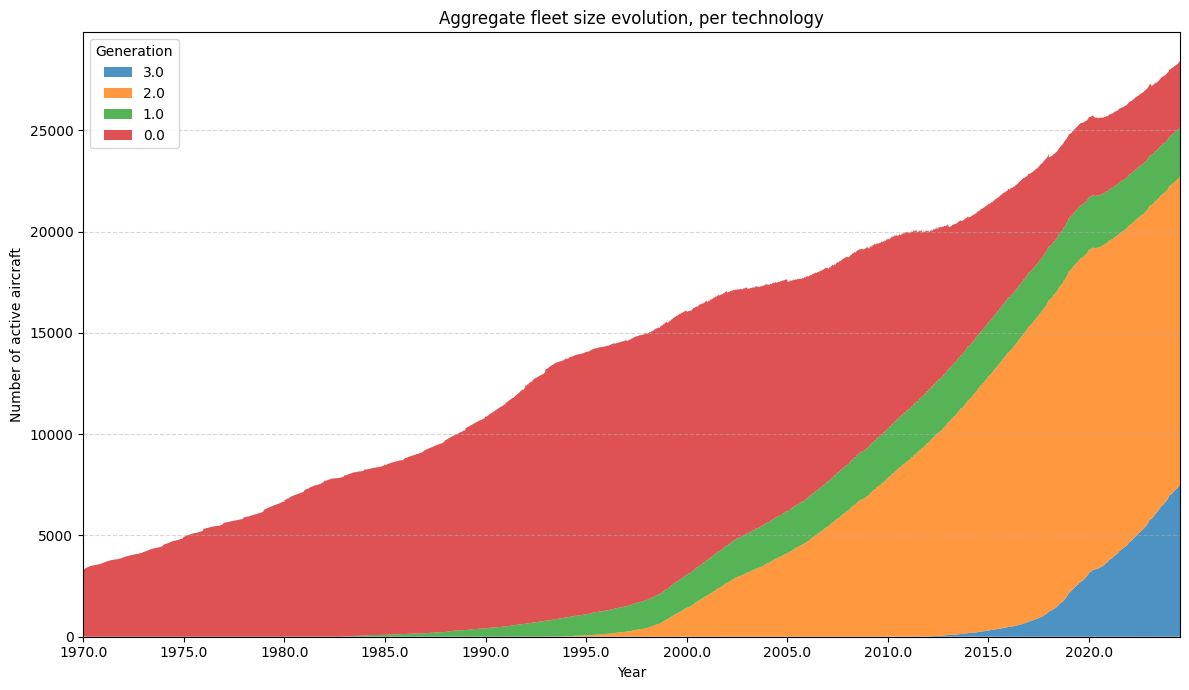

In [58]:
fleet_analysis.visu_fleet(db_selec)

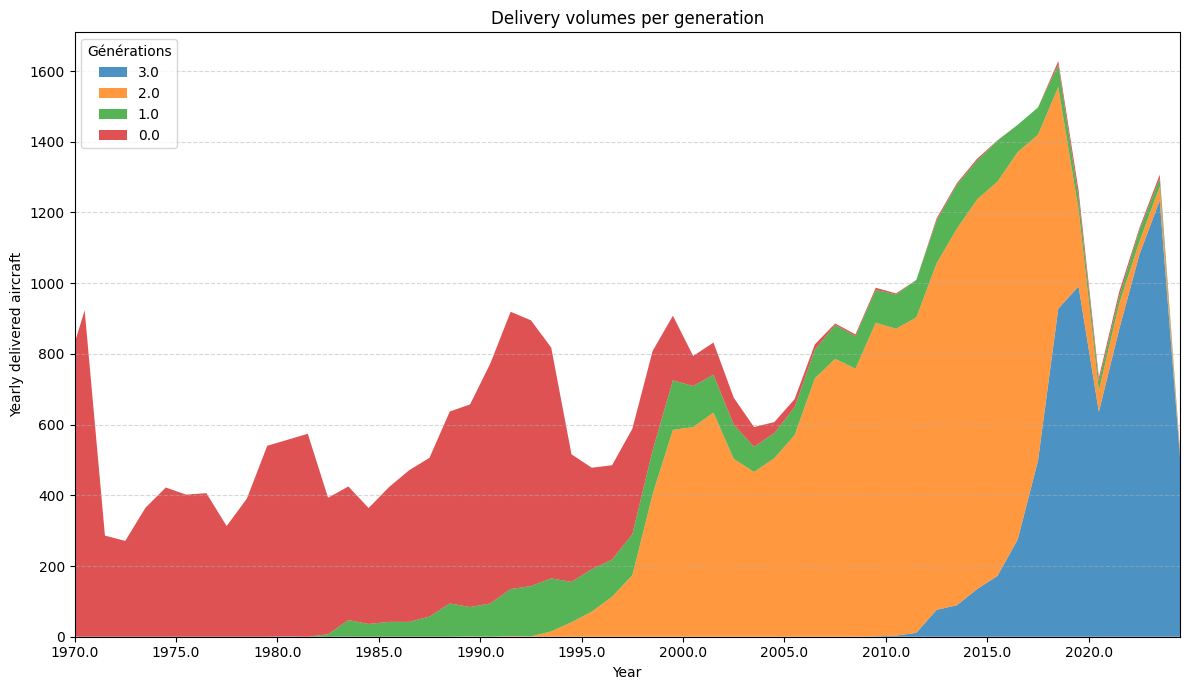

In [59]:
fleet_analysis.visu_prod(db_selec, reso = 1)

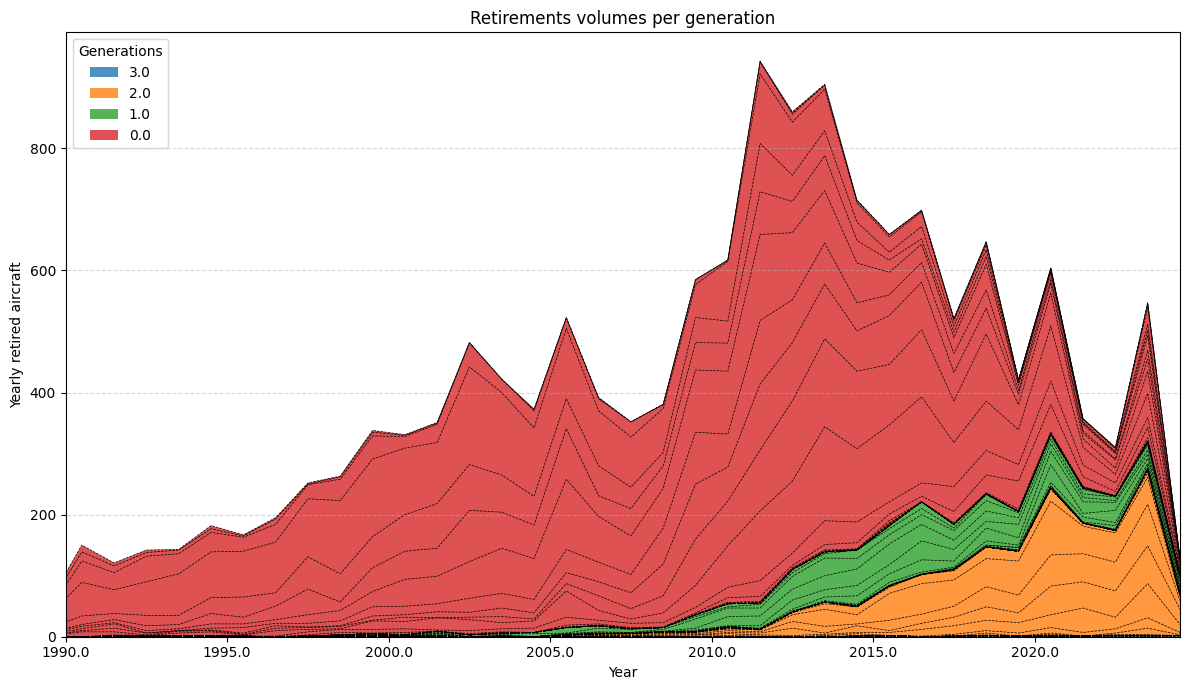

In [87]:
fleet_analysis.visu_retirements(db_selec, reso_1 = 1, reso_2 = 3)

## Model training

In [56]:
db_r = fleet_analysis.retirement_ranking(db_selec)

In [154]:
df_stat = retirement_prio.setting_df(db_r)
# df_stat2 = fleet_analysis.retirement_ranking(df_stat)

# initial 
# stats, y_lims, list_mod = retirement_prio.fit_type_y(df_stat, epoch=1, rep = 20)
#avec chargement du résultat précédent
stats, y_lims, list_mod = retirement_prio.load_prop(title = 'TAA_propension_bts')
# stats = np.where(np.isnan(stats),0, stats)#au cas ou on itère!
# stats, y_lims, list_mod = retirement_prio.fit_type_y(df_stat, epoch=10, rep = 30, vals = stats.T)
# retirement_prio.save_prop(stats.transpose(),list_mod,y_lims, title = 'TAA_propension_bts')

0: -5.1242, -5.1242, reduction needed
-5.1241, -5.124, -5.124, -5.1239, reduction needed
-5.1238, -5.1237, reduction needed
-5.1237, -5.1236, -5.1236, -5.1235, -5.1235, reduction needed
-5.1234, -5.1234, -5.1234, -5.1233, -5.1232, reduction needed
-5.1232, -5.1231, -5.1231, -5.123, -5.123, reduction needed
-5.1229, -5.1229, -5.1229, -5.1228, -5.1227, reduction needed
-5.1227, -5.1226, -5.1226, -5.1225, -5.1225, reduction needed
-5.1224, -5.1224, -5.1224, -5.1223, -5.1222, reduction needed
-5.1222, -5.1221, 
1: -5.1221, reduction needed
-5.1221, -5.122, -5.122, -5.122, -5.1219, -5.1219, -5.1218, -5.1218, -5.1217, reduction needed
-5.1216, -5.1216, -5.1216, -5.1215, -5.1214, -5.1214, -5.1214, -5.1213, reduction needed
-5.1211, -5.121, -5.121, -5.1209, reduction needed
-5.1208, -5.1208, reduction needed
-5.1207, -5.1207, -5.1206, -5.1206, -5.1205, -5.1205, -5.1204, -5.1204, -5.1204, -5.1203, -5.1202, reduction needed
-5.12, -5.12, -5.12, -5.1199, reduction needed
-5.1198, 
2: -5.1198, red

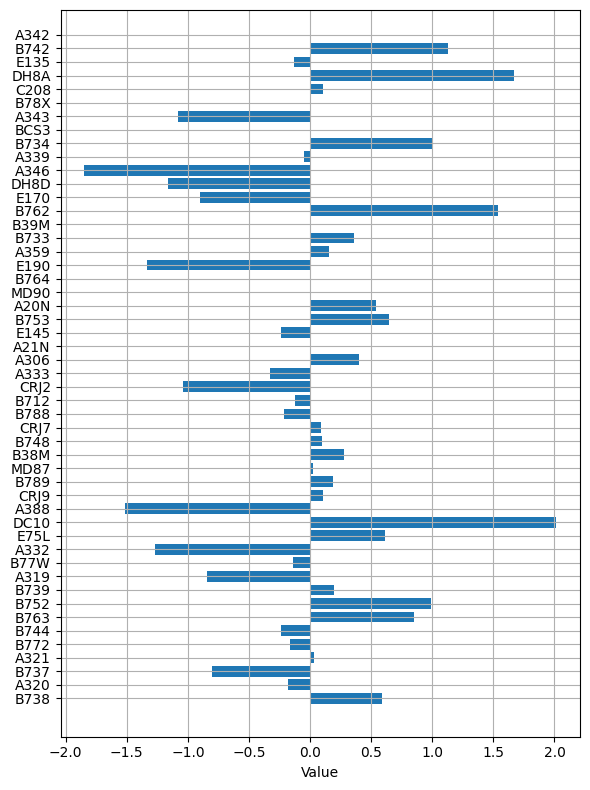

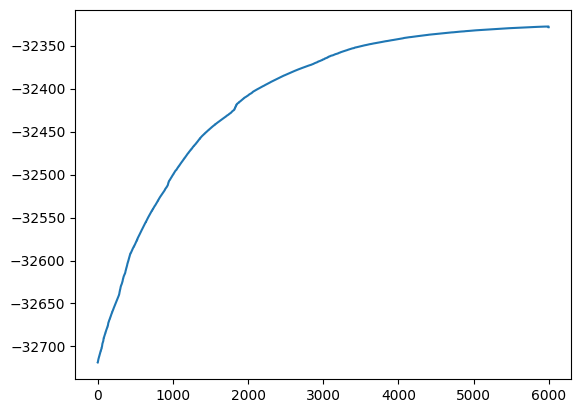

In [57]:
df_stat_lin = retirement_prio.setting_df_lin(db_r)
vals, beta, list_mod = retirement_prio.load_prop_lin(title = 'TAA_propension_lin_icao')
vals = np.where(np.isnan(vals),0, vals)#au cas ou on itère!
vals, beta, list_mod = retirement_prio.fit_type_y_lin(df_stat_lin, epoch=150, rep = 40, m_ref = -8, vals= vals,
                                                        beta = beta,dico2_inv = dico2_inv, n_ac = 50)
retirement_prio.save_prop_lin(vals.transpose(),beta,list_mod, title = 'TAA_propension_lin_icao')

In [58]:
beta

np.float64(0.2228754716595084)

# Aircraft productivity

## Loading data

In [3]:
individual_stops = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\eurocontrol data_archive//flights_ind_anal.csv')
individual_stops.drop(columns=['Unnamed: 0.1', 'Unnamed: 0','Taille_f', 
                               'Siege_ADES', 'Siege_ADEP', 'Siege', 'Tot siege', 'mean_distance','Actual Distance Flown (nm)'],
                     inplace = True)
individual_stops.rename(columns={'AC Type': 'Aircraft Type', 'AC Operator':'Aircraft Operator','AC Registration':'Aircraft Registration',
                                 'ADES_nf': 'ADES +1', 'ADEP_nf' : 'ADEP +1', 'ADEP_pf': 'ADEP -1', 'ADES_pf': 'ADES -1',
                                'echantillon':'Period','time_delta': 'Real Flight Duration', 'time_delta2':'Planned Flight Duration',
                                'time_delta_nf': 'Real Flight Duration +1', 'time_delta2_nf':'Planned Flight Duration +1',
                                 'time_delta_pf': 'Real Flight Duration -1', 'time_delta2_pf':'Planned Flight Duration -1',
                                 'delta_flights' : 'Ground Time', 'delta_pre_flights' : 'Ground Time -1'}, inplace = True)

#standards correction eurocontrol pour mettre des GTs
# individual_stops['Planned Flight Duration +1'] = individual_stops['Planned Flight Duration +1']+0.1
# individual_stops['Ground Time'] = individual_stops['Ground Time']-0.1
# individual_stops['Planned Flight Duration -1'] = individual_stops['Planned Flight Duration -1']+0.1
# individual_stops['Ground Time -1'] = individual_stops['Ground Time -1']-0.1

In [2]:
flights_streaks = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\eurocontrol data_archive//flights_long_anal.csv')
flights_streaks['FILED OFF BLOCK TIME'] = pd.to_datetime(flights_streaks['FILED OFF BLOCK TIME'], utc=True).dt.tz_localize(None)
flights_streaks['FILED ARRIVAL TIME'] = pd.to_datetime(flights_streaks['FILED ARRIVAL TIME'], utc=True).dt.tz_localize(None)
flights_streaks['FILED OFF BLOCK TIME'] = pd.to_datetime(flights_streaks['ACTUAL OFF BLOCK TIME'], utc=True).dt.tz_localize(None)
flights_streaks['FILED ARRIVAL TIME'] = pd.to_datetime(flights_streaks['ACTUAL ARRIVAL TIME'], utc=True).dt.tz_localize(None)
flights_streaks.drop(columns=['Unnamed: 0.2','Unnamed: 0.1', 'Unnamed: 0','Taille_f', 'ADES_nf', 'ADEP_nf',
                              'ADEP_pf', 'ADES_pf','time_delta','time_delta2', 'time_delta_nf', 'time_delta2_nf',
                                 'time_delta_pf', 'time_delta2_pf','delta_flights' , 'delta_pre_flights',
                               'Siege_ADES', 'Siege_ADEP', 'Siege', 'Tot siege', 'mean_distance','Actual Distance Flown (nm)'],
                     inplace = True)
flights_streaks.rename(columns={'AC Type': 'Aircraft Type', 'AC Operator':'Aircraft Operator',
                                'AC Registration':'Aircraft Registration', 'echantillon':'Period'}, inplace = True)

In [7]:
flights_streaks= flights_streaks[flights_streaks['echantillon']<20]
print(flights_streaks[flights_streaks['Actual Distance Flown (nm)']<1500/1.852].shape)
print(flights_streaks[flights_streaks['Actual Distance Flown (nm)']>4000/1.852].shape)
print(flights_streaks[(flights_streaks['Actual Distance Flown (nm)']>1500/1.852)&(flights_streaks['Actual Distance Flown (nm)']<4000/1.852)].shape)
print(flights_streaks[['Actual Distance Flown (nm)','AC Registration','echantillon']].groupby(['AC Registration','echantillon']).count().shape)
print(flights_streaks[['Actual Distance Flown (nm)','AC Registration']].groupby(['AC Registration']).count().shape)
flights_streaks.drop(columns=['Unnamed: 0.2','Unnamed: 0.1', 'Unnamed: 0','Taille_f', 'ADES_nf', 'ADEP_nf',
                              'ADEP_pf', 'ADES_pf','time_delta','time_delta2', 'time_delta_nf', 'time_delta2_nf',
                                 'time_delta_pf', 'time_delta2_pf','delta_flights' , 'delta_pre_flights',
                               'Siege_ADES', 'Siege_ADEP', 'Siege', 'Tot siege', 'mean_distance','Actual Distance Flown (nm)'],
                     inplace = True)
flights_streaks.rename(columns={'AC Type': 'Aircraft Type', 'AC Operator':'Aircraft Operator','AC Registration':'Aircraft Registration',
                                'echantillon':'Period'}, inplace = True)

(5639644, 32)
(415021, 32)
(1718777, 32)
(58177, 1)
(4752, 1)


## Data visualisation individual stops

In [43]:
productivity_analysis.GT_density(individual_stops, FT_min = 0.5, name_fig = 'GT_density_3',sigma = 0.005, reso = 1000)

In [42]:
productivity_analysis.TATs_matrix(individual_stops, x_min = 0.5, y_min = 0.5, name_fig= 'Full_df2', reso = 1000, sigma = 0.015)

5.4% are not b&f flights


## Data visualisation flight streaks

In [26]:
aircraft_ex = flights_streaks[(flights_streaks['Aircraft Registration']=='FGKXY')&(flights_streaks['Period']==17)] #B77w
x_min = productivity_analysis.visu_distrib(aircraft_ex, titre = 'hour_distrib_A320', visu = True, visu_c = True)[0]
productivity_analysis.visu(aircraft_ex, titre = 'A320', visu = True, x_min = x_min)


In [10]:
L_NB = ['B738', 'A320', 'A319', 'A20N', 'A321', 'A21N', 'B38M', 'B752','B737',  'B739','A318',
        'B712','B733','B736','B735','B753','MD11','MD82','B39M','B734'] #NB classiques
LC = ['RYR', 'EZY', 'WZZ', 'VLG']
LL = ['AFR', 'KLM', 'BAW', 'DLH', 'SAS', 'TAP', 'IBE', 'SWR']
selec = flights_streaks[(flights_streaks['Aircraft Type'].isin(L_NB))&(flights_streaks['Period']<20)&((flights_streaks['Period']%4==1)|(flights_streaks['Period']%4==2))]
flight_grouping = productivity_analysis.constru_flight_streak(selec)
productivity_analysis.visu_flight_streaks(flight_grouping,title = 'regimes_hs2', min_fh = 0.5, 
                                          max_fh = 6,reso = 400, sigma = 0.02, n_s = 3)

0%, 5%, 10%, 15%, 20%, 25%, 30%, 35%, 40%, 45%, 50%, 55%, 60%, 65%, 70%, 75%, 80%, 85%, 90%, 95%, 100%, 100 %, ok.
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, ok.


In [28]:
selec = flights_streaks[(flights_streaks['Period']<20)&(flights_streaks['Aircraft Type'].isin(['A332', 'A333']))]
# selec = flights_streaks[(flights_streaks['Period']<20)]
flight_grouping = productivity_analysis.constru_flight_streak(selec)
productivity_analysis.visu_flight_streaks(flight_grouping,title = 'regimes_a33_3', min_fh = 2, 
                                          max_fh = 14,reso = 400, sigma = 0.03, n_s = 2)

0%, 5%, 10%, 15%, 20%, 25%, 30%, 35%, 40%, 45%, 50%, 55%, 60%, 65%, 70%, 75%, 80%, 85%, 90%, 95%, 100 %, ok.
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, ok.


In [18]:
flight_grouping_2 = flight_grouping[flight_grouping[:,1]/flight_grouping[:,3]>0]
productivity_analysis.streaks_matrix(flight_grouping_2,title = 'streak_matrix_a33_2', min_fh = 0.5, 
                                          max_fh = 14,reso = 1000, sigma = 0.02)

## Model training

Mean Squared Error: 11.920657769646272
R-squared: 0.03828387645108433


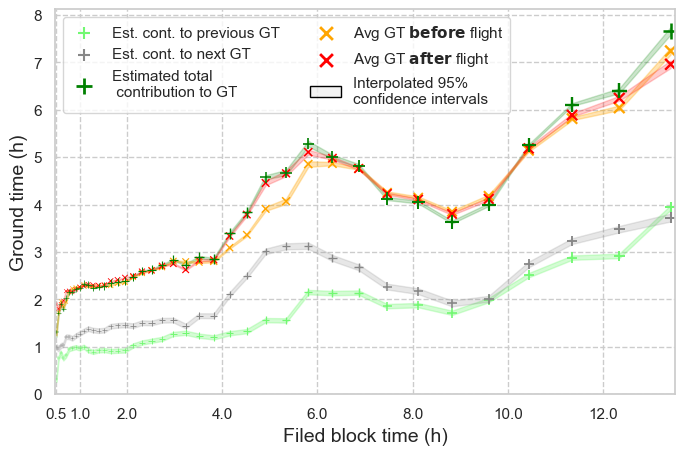

In [12]:
# individual_stops_reg = individual_stops[(individual_stops['Period']<20)&((individual_stops['Period']%4==1)|(individual_stops['Period']%4==2))]
individual_stops_reg = individual_stops[(individual_stops['Period']<20)]
productivity_causality.tat_reg(individual_stops_reg, 'EC_preCOVID', reso = 40)

#La suite ?

# Assignment on routes

## Loading data

#### BTS

In [2]:
y_min = 2015 #1990 , normalement
y_max = 2024 #pour le modèle entraîné

bts_ICAO_names = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Travail de Tobias\Technical Data Aircrafts//aircraft_codes_icao_joined.csv', sep = ';')
print('If one wishes to merge bts and ec, then it requires, ec formalism (less strict), and identifying the type with the ICAO_Code, not Description')
bts_ICAO_names.rename(columns = {'AIRCRAFT_TYPE' : 'Aircraft Type','Description':'Aircraft Type Name'}, inplace = True)
bts_ICAO_names['Aircraft Type'] = bts_ICAO_names['Aircraft Type'].astype(str)

traff_1 = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\data_planes_bts\data_full_airlines\\' + str(y_min) + '\T_T100_SEGMENT_ALL_CARRIER.csv')
for y in range(y_min+1, y_max+1):
    if y%5 == 0 :
        print(y)
    df = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\data_planes_bts\data_full_airlines\\' + str(y) + '\T_T100_SEGMENT_ALL_CARRIER.csv')
    traff_1 = pd.concat([traff_1, df], ignore_index=True)

traff_1.rename(columns = {'ORIGIN_AIRPORT_ID' : 'ADEP','DEST_AIRPORT_ID': 'ADES', 'YEAR':'Period', 'DEPARTURES_PERFORMED': 'N_flights','DISTANCE':'Distance',
                          'AIRCRAFT_TYPE': 'Aircraft Type', 'UNIQUE_CARRIER' : 'Aircraft Operator','UNIQUE_CARRIER_NAME':'Aircraft Operator Name', 'SEATS': 'Seats'}, inplace = True)  
traff_1['Aircraft Type'] = traff_1['Aircraft Type'].astype(str)
bts_ICAO_names = bts_ICAO_names.drop(columns=['Aircraft Type Name']).rename(columns ={'ICAO_Code':'Aircraft Type Name'}) #ligne pour l'analyse directe ICAO
traff_1 = pd.merge(traff_1, bts_ICAO_names[['Aircraft Type', 'Aircraft Type Name']], on = ['Aircraft Type'])

If one wishes to merge bts and ec, then it requires, ec formalism (less strict), and identifying the type with the ICAO_Code, not Description
2020


152 152
new seats, ok
Poids
synthesis...


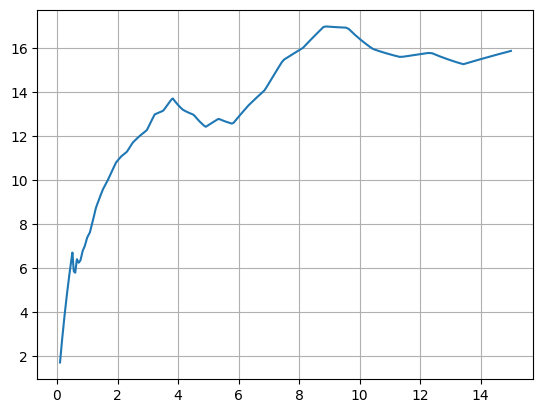

ok


In [3]:
### Version seats équivalents écos
main_Aircrafts = ['B738', 'A320', 'A319', 'A20N', 'A321', 'A21N', 'B38M', 'AT76', 'E190',
       'B77W', 'B789', 'A333', 'E195', 'CRJ9', 'AT75', 'DH8D', 'BCS3', 'A332','A338',
       'B788', 'A359', 'B77L', 'DH8A', 'B763', 'B734', 'B772', 'CRJX', 'B752',
       'C56X', 'B737', 'S92', 'B739', 'B744', 'E55P', 'E75L', 'SU95', 'A388',
       'AT72', 'E145', 'E170', 'A306', 'AT45', 'E295', 'SF34', 'B748', 'A318',
       'C25A', 'A339', 'F2TH', 'B733', 'C68A', 'CL35', 'E35L', 'A35K', 'E75S',
       'E290', 'PC12', 'GLEX', 'C510', 'C525', 'DH8B', 'B78X', 'A343', 'CRJ2',
       'BE20', 'BCS1', 'CL60', 'PC24', 'C25B', 'A139', 'AT43',
        'B736','B735', 'RJ1H','B712', 'SB20','F100','A346','CRJ7','H25B',
          'B753','B762','B764','F50','JS41','ATP' , 'DH8C',
        'D328', 'A310','MD11','C680','JS32','MD81','MD82','MD88','FA7X','J328',
        'BE40','D228','CL30','C550','E120','SW4',
         'E135', 'E50P','GLF5','L410','F900','AT46','C650',
        'LJ60','B463','DHC6','B39M','B742', 'B773', 'A30B', 'F70',
         'MD87','B722','B732','DC93','B743', 'DC10',
        'L101','B741','DC95','MD90','A342','CRJ1',
        'B721','DC94', 'B74D', 'C208','C402', 'A345',
        'B703', 'B74S','C212', 'AJ27', 'C919', 'CVLT', 'E110',
        'F27', 'F28','L188','DC86', 'DC87','DC91','DC92',
        'SH33','SH36'] #115 avions, 98% des vols

Appr_max_seats = [175, 180, 145, 194, 228, 244, 200, 78, 100,
            368, 420, 440, 146, 90, 78, 78, 160, 406,406,
            380, 440, 440, 78, 328, 150, 440, 100, 240,
            9, 143, 24, 167, 660, 10, 80, 103, 853, #A380
            78, 50, 70, 266, 50, 146, 36, 605, 132,
            10, 440, 19, 140, 9, 12, 37, 480, 76, #E75S
            100, 8, 18, 5, 6, 78, 440, 365, 50,
            10, 135, 30, 10, 10, 15, 48,
            132, 140, 100, 134, 58, 109, 350, 68, 9,#H25B
            290, 290, 400, 56, 30, 68, 56,
            30, 280, 380, 11, 19, 172, 172, 172, 19, 43, #J328
             4, 19, 16, 8, 30, 19, 
               37, 7, 14, 19, 19, 48, 15, #C650
              8, 100, 20, 240, 550, 550, 345,70,
            140, 189, 130, 127, 608, 380, #DC10
            315, 550,127, 187, 335, 52, 
            189, 127, 200, 14, 10, 390, #A345
            200, 400, 26, 90, 190, 52, 18,
            56, 80, 98, 270, 270,90,90, #DC92
             33,39 ] #configurations denses en classe éco.
print(len(main_Aircrafts), len(Appr_max_seats))
sizes_ac =dict(zip(main_Aircrafts,Appr_max_seats))

mask = traff_1['Aircraft Type Name'].isin(sizes_ac)
traff_1.loc[mask, 'Seats'] = traff_1.loc[mask, 'Aircraft Type Name'].map(sizes_ac)*traff_1.loc[mask, 'N_flights']
print('new seats, ok')
traff_1 = traff_1[(traff_1['Seats']>0)]
traff_1 = traff_1[traff_1['N_flights']>0]
traff_1['Distance'] = traff_1['Distance']*1.852
traff_1 = traff_1[traff_1['Distance']>80] #filtres sur le noùbre de km
traff_1['ADEP Name'] = traff_1['ADEP'] #a adapter bien sur
traff_1['ADES Name'] = traff_1['ADES'] #a adapter bien sur
traff_1.drop(columns=['PASSENGERS'], inplace = True)
print('Poids')
airports = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\data_planes_bts//T_MASTER_CORD.csv')[['AIRPORT_ID','AIRPORT_COUNTRY_NAME']]
airports_us = airports[airports['AIRPORT_COUNTRY_NAME']=='United States']
airports_not_us = airports[airports['AIRPORT_COUNTRY_NAME']!='United States']
us_id = airports_us['AIRPORT_ID'].unique() #contient porto rico et des iles
not_us_id = airports_not_us['AIRPORT_ID'].unique() #contient porto rico et des iles (priorité aux us)
# print(traff_1.shape,traff_1['ADES'].isin(us_id).sum()+(traff_1['ADES'].isin(not_us_id)&(~traff_1['ADES'].isin(us_id))).sum()) #ok à quelques vols près
traff_1['Weight']= 0
traff_1.loc[traff_1['ADES'].isin(us_id), 'Weight']+=0.5
traff_1.loc[traff_1['ADEP'].isin(us_id), 'Weight']+=0.5
traff_1 = assignment_analysis.agg_ind_1(traff_1) 
traff_1 = assignment_analysis.agg_ind_s(traff_1, observation ='ASK') 
productivity_modelling.activity_assignment(traff_1, 'EC_preCOVID')
traff_1 = assignment_analysis.agg_ind_s(traff_1, observation ='Av ac seats') 
traff_1 = assignment_analysis.agg_ind_s(traff_1, observation ='N_flights') 
traff_1['Aircraft Type'] = traff_1['Aircraft Type Name'] #synthèse des id ICAO
print('ok')

In [ ]:
### Version classique
traff_1 = traff_1[(traff_1['Seats']>0)]
traff_1 = traff_1[traff_1['N_flights']>0]
traff_1['Distance'] = traff_1['Distance']*1.852
traff_1 = traff_1[traff_1['Distance']>80] #filtres sur le noùbre de km
traff_1['ADEP Name'] = traff_1['ADEP'] #a adapter bien sur
traff_1['ADES Name'] = traff_1['ADES'] #a adapter bien sur
traff_1.drop(columns=['PASSENGERS'], inplace = True)
print('Poids')
airports = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\data_planes_bts//T_MASTER_CORD.csv')[['AIRPORT_ID','AIRPORT_COUNTRY_NAME']]
airports_us = airports[airports['AIRPORT_COUNTRY_NAME']=='United States']
airports_not_us = airports[airports['AIRPORT_COUNTRY_NAME']!='United States']
us_id = airports_us['AIRPORT_ID'].unique() #contient porto rico et des iles
not_us_id = airports_not_us['AIRPORT_ID'].unique() #contient porto rico et des iles (priorité aux us)
# print(traff_1.shape,traff_1['ADES'].isin(us_id).sum()+(traff_1['ADES'].isin(not_us_id)&(~traff_1['ADES'].isin(us_id))).sum()) #ok à quelques vols près
traff_1['Weight']= 0
traff_1.loc[traff_1['ADES'].isin(us_id), 'Weight']+=0.5
traff_1.loc[traff_1['ADEP'].isin(us_id), 'Weight']+=0.5
traff_1 = assignment_analysis.agg_ind_1(traff_1) 
traff_1 = assignment_analysis.agg_ind_s(traff_1, observation ='ASK') 
productivity_modelling.activity_assignment(traff_1, 'EC_preCOVID')
traff_1 = assignment_analysis.agg_ind_s(traff_1, observation ='Av ac seats') 
traff_1 = assignment_analysis.agg_ind_s(traff_1, observation ='N_flights') 
print('ok')

### Eurocontrol

synthesis...


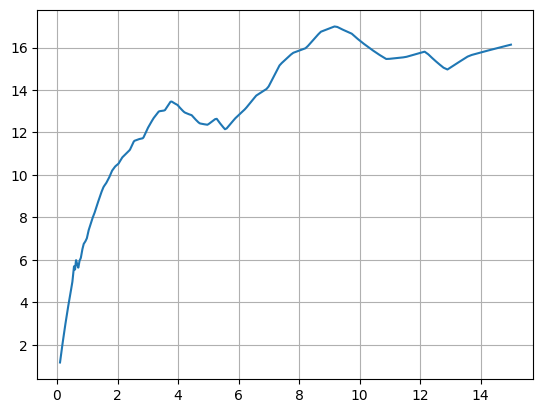

In [2]:
traff_2 = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\eurocontrol data_archive//flights_market_an_agg.csv')
traff_2.drop(columns=['Unnamed: 0','Siege_ADES', 'Siege_ADEP', 'Siege'], inplace = True)
traff_2['mean_distance'] = traff_2['mean_distance']*1.852
traff_2.rename(columns ={'AC Type':'Aircraft Type', 'AC Operator':'Aircraft Operator', 'echantillon':'Period', 
                         'Taille_f':'Seats', 'tau':'Weight', 'mean_distance':'Distance'}, inplace = True)
traff_2['ADEP Name']=traff_2['ADEP']
traff_2['ADES Name']=traff_2['ADES']
traff_2['Aircraft Type Name']= traff_2['Aircraft Type']
traff_2['Aircraft Operator Name']=traff_2['Aircraft Operator']
traff_2 = assignment_analysis.agg_ind_1(traff_2) 
traff_2 = assignment_analysis.agg_ind_s(traff_2, observation ='ASK') 
traff_2['Seats_conn_p'] = traff_2['Seats_conn_p']*12
traff_2['ASK_conn_p'] = traff_2['ASK_conn_p']*12
productivity_modelling.activity_assignment(traff_2, 'EC_preCOVID2')
traff_2 = assignment_analysis.agg_ind_s(traff_2, observation ='Av ac seats')

## Data visualisation (#peut être à revoir pour séparer les densités d'affichage de la fréquentation par connection)

In [39]:
assignment_analysis.market_vis(traff_2[traff_2['Period'].isin([16,17,18,19])], name_fig = 'Eurocontrol_2019_act_w',reso = 400, smooth_param = 0.05, 
                                  market = 'Aircraft Type', observation = 'Av ac seats', dist_limits = [2.5e2, 1.6e4], 
                                  capac_limits = [4.9e3, 4.9e6], n_market = 19, weight = True)
# traff_2.loc[traff_2['Period'].isin([17,18]),'Period'] = -1
# traff_2.loc[traff_2['Period'].isin([16,19]),'Period'] = -2
# ####on corrige un facteur 6 dans les tailles de graphe
# assignment_analysis.dynamic_market_vis(traff_2, [-1,-2],name_periods = ['Summer 2019', 'Winter 2019'], video_name = 'test_market_Type',reso = 300, smooth_param = 0.05, 
#                                   market = 'Aircraft Type', observation = 'ASK', dist_limits = [2.5e2, 1.6e4], period_ref = -2,
#                                   capac_limits = [4.9e3, 4.9e6], n_market = 16, format_v='video', period_duration = 1, weight = True)

In [28]:
FB_seymm = pd.read_csv('D:/p.viry/Documents/Travail_recherche/Data/FB models ext/ac_model_coefficients.csv')
FB_seymm = FB_seymm[FB_seymm['ac_code_icao'].isin(list(traff_1['Aircraft Type Name'].unique()))].drop(columns = ['Unnamed: 0'])
traff_1 = traff_1[traff_1['Aircraft Type Name'].isin(list(FB_seymm['ac_code_icao'].unique()))]
FB_seymm.reset_index(inplace = True)
FB_seymm.drop(columns = ['index'], inplace = True)
FB_seymm['index'] =FB_seymm.index

fb_ini = FB_seymm[['reduced_fuel_a1','reduced_fuel_a2', 'reduced_fuel_intercept']].values
fb_ini = np.concatenate([fb_ini, np.array(4*[[0,3,0]]+2*[[0,2,0]]+[[0,0.2,0]]+[[0,2,0]])])

dico_seymm = FB_seymm.set_index('ac_code_icao')['index'].to_dict()
global_modelling.fuel_calculations(traff_1, None, dico_seymm, fb_ini, n_flights = False)
traff_1 = assignment_analysis.agg_ind_s(traff_1, observation ='FB') 
assignment_analysis.market_vis(traff_1[traff_1['Period'].isin([2024])], name_fig = 'market_bts_fb_w_2024',reso = 400, smooth_param = 0.07, 
                                  market = 'Aircraft Type', observation = 'FB', dist_limits = [1.5e2, 1.9e4], 
                                  capac_limits = [2e3, 6e6], n_market = 15, period_duration = 1, weight = True)

5         47
29        70
112       47
124       47
142       47
          ..
917442    47
917443    47
917444    47
917445    47
917446    47
Name: Aircraft Type Name, Length: 871973, dtype: int64


In [6]:
assignment_analysis.market_vis(traff_1[traff_1['Period'].isin([2024])], name_fig = 'market_bts_seats_2024_w',reso = 400, smooth_param = 0.07, 
                                  market = 'Aircraft Type', observation = 'Seats', dist_limits = [1.5e2, 1.9e4], 
                                  capac_limits = [2e3, 6e6], n_market = 15, period_duration = 1, weight = True)

In [139]:
assignment_analysis.assign_vis(traff_1[traff_1['Period'].isin([1990,1991])], [715], title_fig = '715', name_fig = 'test_assign',reso = 400, smooth_param = 0.07, 
                                  market = 'Aircraft Type', observation = 'ASK', dist_limits = [1.5e2, 1.9e4], 
                                  capac_limits = [2e3, 6e6], vmax = 0.5, period_duration = 1)

In [5]:
assignment_analysis.dynamic_market_vis(traff_1, [i for i in range(2015,2025)], video_name = 'history_US_market_new_est',reso = 400, smooth_param = 0.05, 
                                  market = 'Aircraft Type', observation = 'Av ac seats', dist_limits = [1.5e2, 1.9e4], period_ref = 2024,
                                  capac_limits = [2e3, 6e6], n_market = 18, format_v='video', weight = True)

Color choice...
Coloriage trouvé : {'614': 0, '627': 1, '694': 2, '612': 3, '626': 4, '622': 5, '696': 6, '637': 7, '698': 8, '699': 9, '673': 10, '889': 11, '888': 12, '819': 13, '820': 14, '821': 15, '882': 16, '740': 17, '887': 18, '722': 16, '359': 17, '634': 19, '838': 18, '683': 18, '655': 11, '687': 15, '721': 13, '638': 17, '839': 14}
0.0%
30.0%
60.0%
90.0%


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1400, 1000) to (1408, 1008) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [42]:
traff_c = traff_1[traff_1['Aircraft Operator Name']=='Delta Air Lines Inc.']
assignment_analysis.dynamic_market_vis(traff_1, [i for i in range(1990,2025)], video_name = 'Delta_history_US_market',reso = 400, smooth_param = 0.05, 
                                  market = 'Aircraft Type', observation = 'Av ac seats', dist_limits = [1.5e2, 1.9e4], period_ref = 2024,
                                  capac_limits = [2e3, 6e6], n_market = 18, format_v='video')

Color choice...
Coloriage trouvé : {'622': 0, '626': 1, '694': 2, '655': 3, '819': 4, '627': 5, '698': 6, '614': 7, '619': 8, '612': 9, '696': 10, '620': 11, '617': 12, '640': 10, '625': 13, '629': 14, '699': 11, '638': 12, '637': 13, '715': 14, '817': 15, '616': 16, '631': 15, '732': 9, '673': 8, '888': 16, '889': 17, '675': 17, '730': 6, '873': 18, '882': 18, '816': 5, '760': 7, '722': 3, '608': 19, '634': 20, '740': 17, '887': 4, '359': 18, '603': 18, '710': 2, '690': 16, '687': 14, '838': 14, '721': 15, '650': 12, '693': 17, '691': 17, '839': 1}
0.0%
8.571428571428571%
17.142857142857142%
25.714285714285715%
34.285714285714285%
42.857142857142854%
51.42857142857143%
60.0%
68.57142857142857%
77.14285714285714%
85.71428571428571%
94.28571428571429%


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1400, 1000) to (1408, 1008) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [137]:
assignment_analysis.dynamic_assign_vis(traff_1, [715], [1990,1991,1992,1993,1994], format = 'gif', video_name = '715_assign', market = 'Aircraft Type',
                                       observation = 'ASK', dist_limits = [1.5e2, 1.9e4], capac_limits = [2e3, 6e6],
                                      frame_s = 2, color = 'pink', reso = 400, smooth_param = 0.05, period_duration = 1, vmax = 0.5)

0.0%
60.0%


## Model training & evaluation

In [10]:
### data preparation
obs_choice = 'Av ac seats' #'ASK' ou 'Av ac seats'
ds_name='bts'#BTS : 'bts', EUROCONTROL : 'ec'
n_choice = 50
d_norm, cap_norm = 15000, 15

if ds_name == 'bts' :
    traff_s = traff_1[traff_1['Period'].isin([2015,2016,2017,2018,2019,2024])]
    traff_cond = traff_s[['ADEP','ADES','Aircraft Type','Aircraft Type Name', 'Period', 'Distance_conn (km)', 'Weight', 'Seats_conn_p', obs_choice, obs_choice+'_conn_p','N_flights', 'Seats']].groupby(
        ['ADEP','ADES','Aircraft Type','Aircraft Type Name', 'Period', 'Distance_conn (km)', 'Weight', 'Seats_conn_p', obs_choice+'_conn_p']).sum().reset_index()
    df_training, c_table, existence_cache, ranges, connections = assignment_multilogit.data_formatting(traff_cond, n_ac= n_choice, seuils_f = 0.01, weight = True,
                                                                                                   obs = obs_choice, save_techn_carac = True, airports = False) #True seulement pour bts
if ds_name == 'ec' :
    traff_s = traff_2[(traff_2['Period']<=19)]
    traff_cond = traff_s[['ADEP','ADES','Aircraft Type','Aircraft Type Name', 'Period', 'Distance_conn (km)', 'Weight', 'Seats_conn_p', 'ASK_conn_p', 'ASK', 'Seats']].groupby(
        ['ADEP','ADES','Aircraft Type','Aircraft Type Name', 'Period', 'Distance_conn (km)', 'Weight', 'Seats_conn_p', 'ASK_conn_p']).sum().reset_index()
    df_training, c_table, existence_cache, ranges, connections = assignment_multilogit.data_formatting(traff_cond, n_ac= n_choice, seuils_f = 0.01, weight = False,
                                                                                                   obs = obs_choice, save_techn_carac = False, airports = False) #True seulement pour bts

n_y = existence_cache.shape[1]
data_training = np.array(df_training[['Period','Distance_conn (km)','Seats_conn_p','Id_mod',obs_choice+'_w']]) 
obs_norm = data_training[:,4].sum() #les références de d_norm et cap_norm sont fixes dans les modèles
data_training[:,1] = data_training[:,1]/d_norm
data_training[:,2] = np.log(data_training[:,2])/cap_norm
data_training[:,4] = data_training[:,4]/obs_norm

99.2% Av ac seatss selected.


In [11]:
# alphas, betas, omegas, likely = assignment_multilogit.fit_function(data_training, existence_cache, ranges, num_epochs = 50, learning_rate = 0.3, n_y = n_y, n_ac = n_choice, 
#                                                                  title = 'logit_model_'+ds_name+'_'+obs_choice+'_'+str(n_choice)+'_'+str(n_y)+'_'+str(1),
#                                                                    names_ac =list(c_table['Aircraft Type Name']), n_batches = 30)
# alphas, betas, omegas, likely = assignment_multilogit.fit_function(data_training, existence_cache, ranges, num_epochs = 50, learning_rate = 0.2, n_y = n_y, n_ac = n_choice, 
#                                                                  title = 'logit_model_'+ds_name+'_'+obs_choice+'_'+str(n_choice)+'_'+str(n_y)+'_'+str(2),
#                                                                    names_ac =list(c_table['Aircraft Type Name']), n_batches = 5,
#                                                                   alphas = alphas, betas = betas, omegas = omegas)
# alphas, betas, omegas, likely = assignment_multilogit.fit_function(data_training, existence_cache, ranges, num_epochs = 100, learning_rate = 0.2, n_y = n_y, n_ac = n_choice, 
#                                                                  title = 'logit_model_'+ds_name+'_'+obs_choice+'_'+str(n_choice)+'_'+str(n_y)+'_'+str(3),
#                                                                    names_ac =list(c_table['Aircraft Type Name']), n_batches = 2,
#                                                                   alphas = alphas, betas = betas, omegas = omegas)
alphas, betas, omegas = assignment_multilogit.load_estim(name ='logit_model_'+ds_name+'_'+obs_choice+'_'+str(n_choice)+'_'+str(n_y)+'_'+str(4)+'_59')
alphas, betas, omegas, likely = assignment_multilogit.fit_function(data_training, existence_cache, ranges, num_epochs = 1500, learning_rate = 0.05, n_y = n_y, n_ac = n_choice, 
                                                                 title = 'logit_model_'+ds_name+'_'+obs_choice+'_'+str(n_choice)+'_'+str(n_y)+'_'+str(4),
                                                                   names_ac =list(c_table['Aircraft Type Name']), n_batches = 1,
                                                                  alphas = alphas, betas = betas, omegas = omegas)



Without training -2.76601
epoch 0; Log-likelihood = -2.76401
epoch 1; epoch 2; epoch 3; epoch 4; epoch 5; Log-likelihood = -2.74938
epoch 6; epoch 7; epoch 8; epoch 9; epoch 10; Log-likelihood = -2.73971
epoch 11; epoch 12; epoch 13; epoch 14; epoch 15; Log-likelihood = -2.73181
epoch 16; epoch 17; epoch 18; epoch 19; epoch 20; Log-likelihood = -2.72426
epoch 21; epoch 22; epoch 23; epoch 24; epoch 25; Log-likelihood = -2.71656
epoch 26; epoch 27; epoch 28; epoch 29; epoch 30; Log-likelihood = -2.70915
epoch 31; epoch 32; epoch 33; epoch 34; epoch 35; Log-likelihood = -2.702
epoch 36; epoch 37; epoch 38; epoch 39; epoch 40; Log-likelihood = -2.69509
epoch 41; epoch 42; epoch 43; epoch 44; epoch 45; Log-likelihood = -2.68841
epoch 46; epoch 47; epoch 48; epoch 49; epoch 50; Log-likelihood = -2.68197
epoch 51; epoch 52; epoch 53; epoch 54; epoch 55; Log-likelihood = -2.67576
epoch 56; epoch 57; epoch 58; epoch 59; epoch 60; Log-likelihood = -2.66979
epoch 61; epoch 62; epoch 63; epoch 64

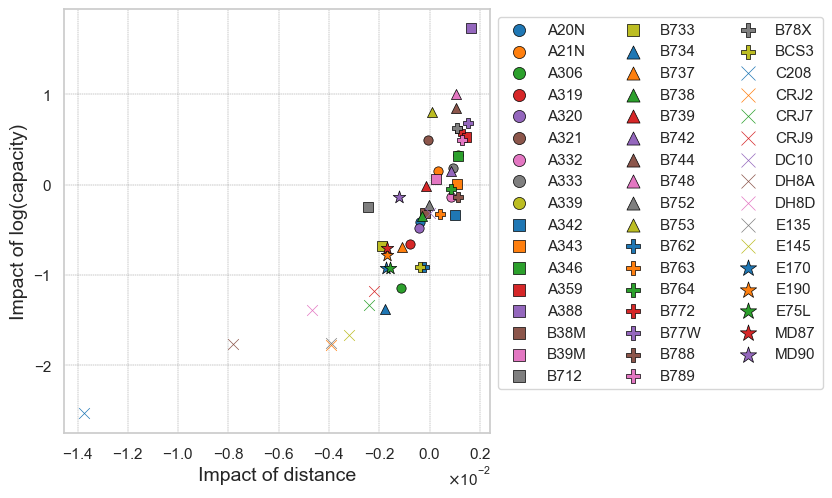

avg relative error : 0.0392066961628134
obs_weighted avg relative error : 0.03352157107844915


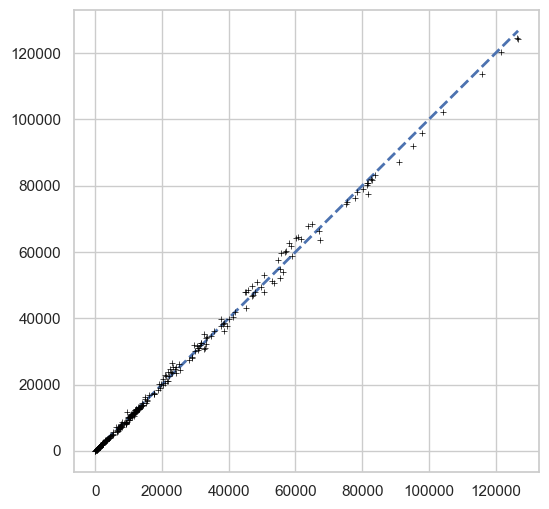

0.07151210138835516 0.14384113314158695


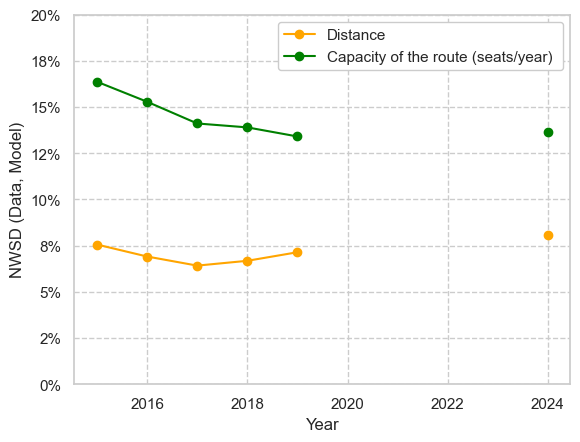

In [13]:
alphas, betas, omegas, names_ac = assignment_multilogit.load_estim(name ='logit_model_'+ds_name+'_'+obs_choice+'_'+str(n_choice)+'_'+str(n_y)+'_'+str(4)+'_29', columns = True)
assignment_multilogit.visu_coeffs(alphas, betas, names_ac,ds_name, d_norm = d_norm, cap_norm= cap_norm)
connec_training = np.array(connections[['Period', 'Distance_conn (km)','Seats_conn_p',obs_choice+'_w_mod']])
shares_pred = assignment_multilogit.predict_assignt(connec_training, existence_cache,alphas,betas,omegas,ranges, d_norm=d_norm, cap_norm=cap_norm)
assignment_multilogit.obs_comp(data_training, connec_training, shares_pred, obs_norm)
assignment_multilogit.nwsd(existence_cache, data_training, connec_training, shares_pred, d_norm, cap_norm,obs_norm, year_ref = 2015, freq = 1)

MSE : 16.343e-8
R^2 : 0.976


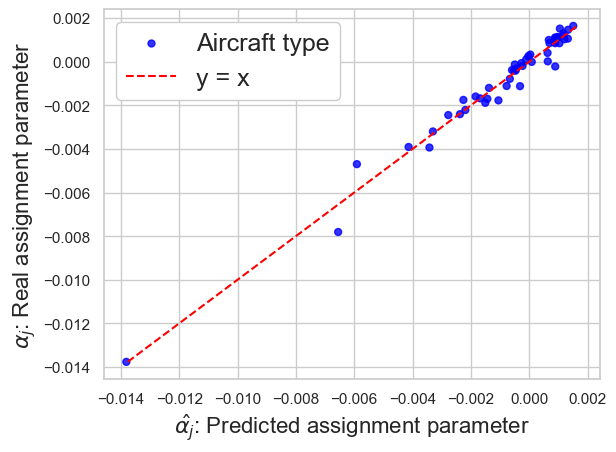

MSE : 1.342e-1
R^2 : 0.810


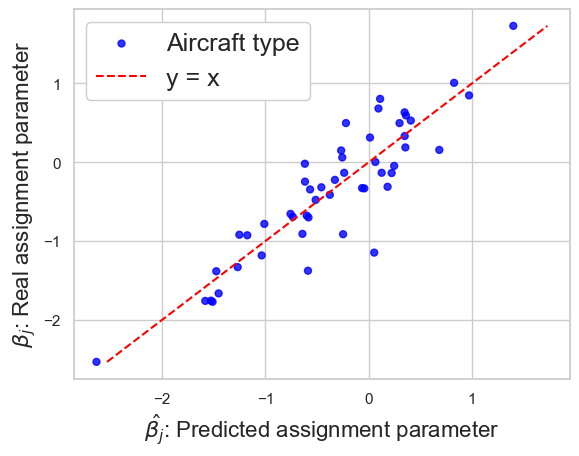

MSE : 6.680e-8
R^2 : 0.958


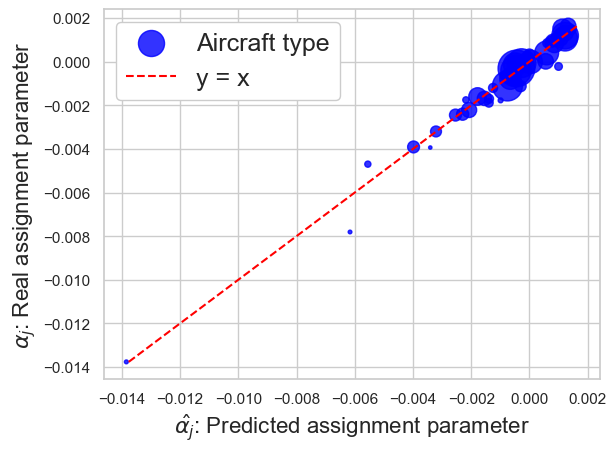

MSE : 1.043e-1
R^2 : 0.766


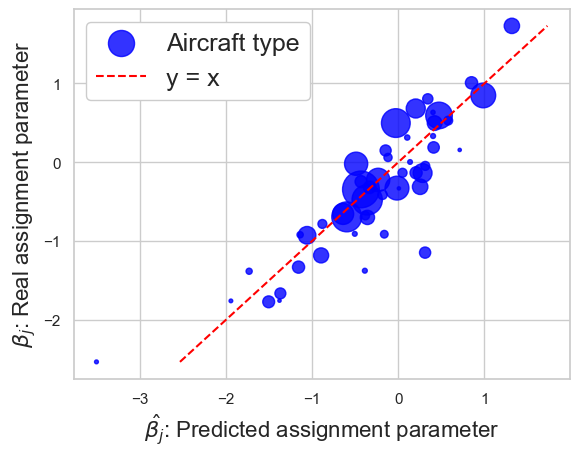

MSE : 6.474e-8
R^2 : 0.948


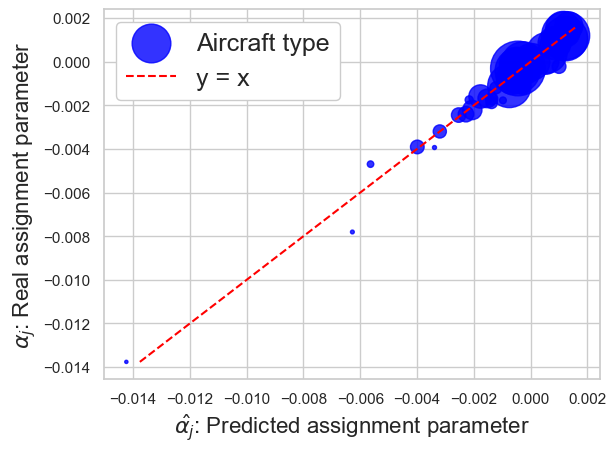

MSE : 1.043e-1
R^2 : 0.766


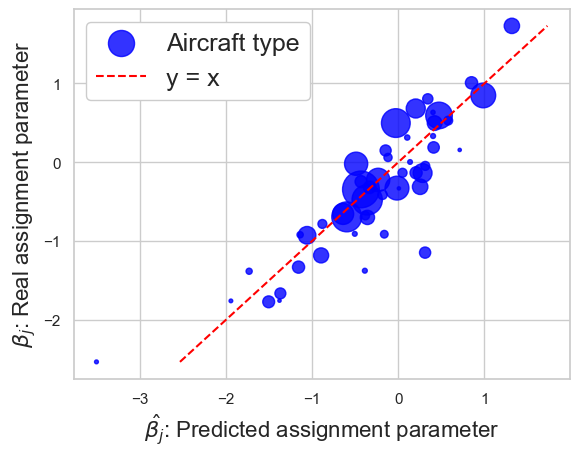

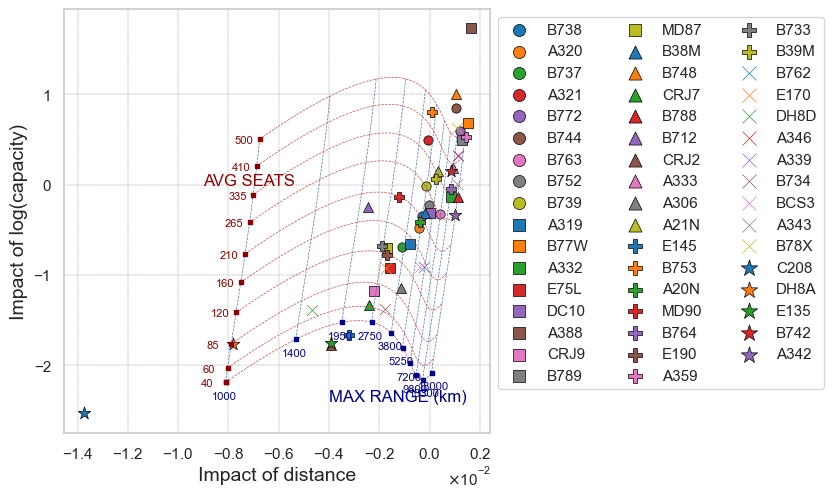

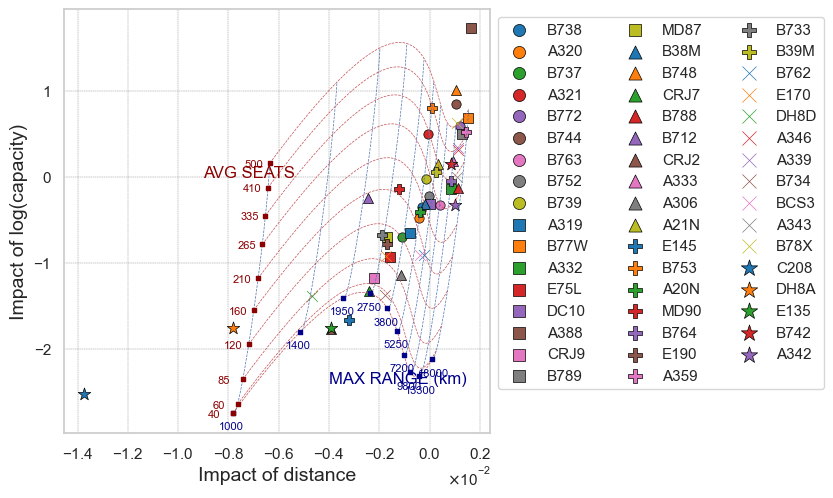

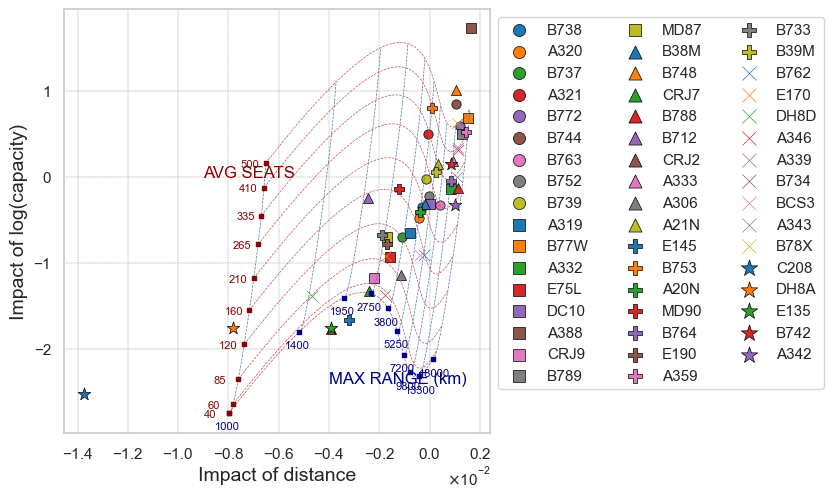

In [14]:
#strictement réservé à BTS, associé à une bdd technique.
correspondance_table = assignment_multilogit.correspondance_table(title_coeffs = 'logit_model_bts_Av ac seats_50_10_4_29',title_tech = 'BTS_Av ac seats_50_10', obs_choice = 'Av ac seats', d_norm = d_norm, cap_norm= cap_norm)
coeffs_alphas, coeffs_betas =assignment_multilogit.regressor_assign_coeffs(correspondance_table, weight = False, obs_choice = obs_choice)
coeffs_alphas_w, coeffs_betas_w = assignment_multilogit.regressor_assign_coeffs(correspondance_table, weight = True, obs_choice = obs_choice)
coeffs_alphas_wl, coeffs_betas_wl = assignment_multilogit.regressor_assign_coeffs(correspondance_table, weight = True,weight_log = True, obs_choice = obs_choice)

assignment_multilogit.regressor_visu_model(correspondance_table,coeffs_alphas, coeffs_betas, reg_name='bts_activity_50_9')
assignment_multilogit.regressor_visu_model(correspondance_table,coeffs_alphas_w, coeffs_betas_w, reg_name='bts_activity_50_9_w')
assignment_multilogit.regressor_visu_model(correspondance_table,coeffs_alphas_wl, coeffs_betas_wl, reg_name='bts_activity_50_9_wl')

alpha_mod, beta_mod, seats_mod, ranges_mod = assignment_multilogit.assign_coeffs_pred(coeffs_alphas_w, coeffs_betas_w, 180, 9000)

# Scenarios

## Simple illustrative scenario

Scenario très simple test :  trois modèles d avions, 4 connections et 4 périodes
year 0,total fleet: 800.8280135667342
total constraint: 650.0
Fleet content, ok.
Fleet assignment, ok.
Year 0 done.
year 1,total fleet: 1116.0756951603553
total constraint: 710.0
Fleet content, ok.
Fleet assignment, ok.
Year 1 done.
year 2,total fleet: 1286.7795865201472
total constraint: 800.0
Fleet content, ok.
Fleet assignment, ok.
Year 2 done.
year 3,total fleet: 1890.1065176274374
total constraint: 840.0
Fleet content, ok.
Fleet assignment, ok.
Year 3 done.
{np.int64(0): 1, np.int64(2): 2, np.int64(1): 3}


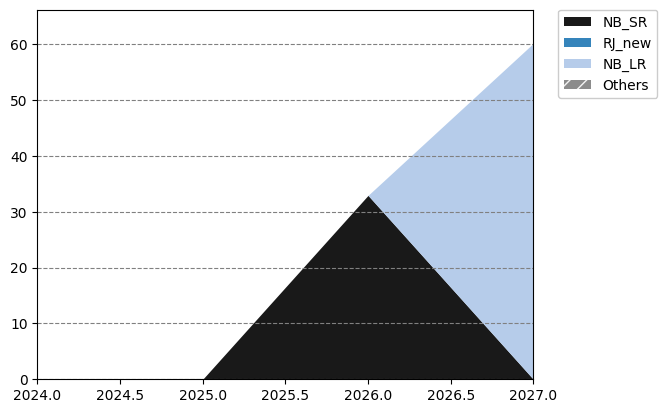

Color choice...
Coloriage trouvé : {1: 0, 0: 1, 2: 2}
0.0%


TypeError: list indices must be integers or slices, not NoneType

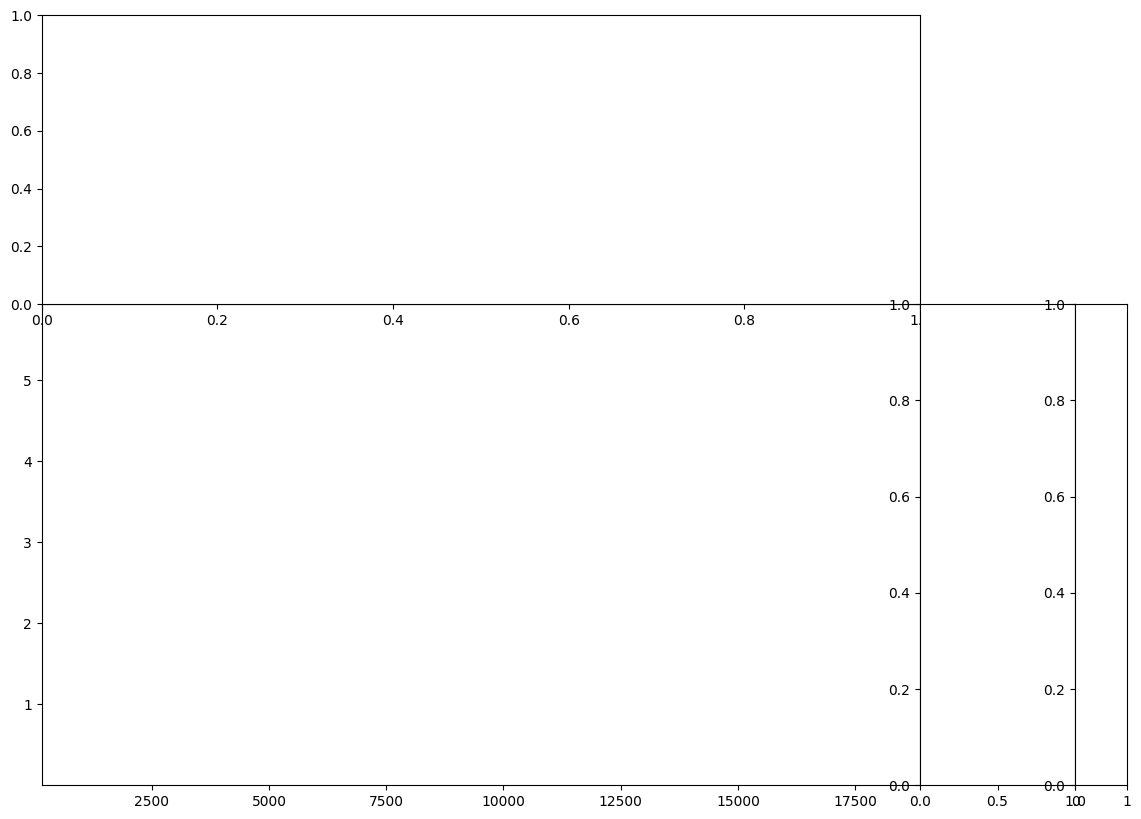

In [55]:
print('Scenario très simple test :  trois modèles d avions, 4 connections et 4 périodes')
types_names = ['NB_SR', 'NB_LR', 'RJ_new']
alphas = np.array([0,1e-3, 2e-3])
betas = np.array([0,1,-1 ])
ranges = np.array([3500,3500, 2100])
omegas_0 = np.array([0.0,0.0,0.0])[:, np.newaxis]

initial_fleet = np.array([[2,1,0],[1,2,0],[0,0,0],[0,0,0],[0,0,0],[0,0,0]]) 
deliveries = np.array([[[0,0,0],[0,0,0],[2,2,0],[0,0,0],[0,0,0],[0,0,0]],
                       [[0,0,0],[0,0,0],[0,0,0],[2,2,0],[0,0,0],[0,0,0]],
                       [[0,0,0],[0,0,0],[0,0,0],[0,0,0],[0,1,2],[0,0,0]],
                       [[0,0,0],[0,0,0],[0,0,0],[0,0,0],[0,0,0],[4,3,1]]]) 
obs_sizes = np.array([80, 80, 50])
retirement_prop = np.array([[-8,-8,-8],[1,1,1],[2,2,2],[3,3,3],[4,4,4],[6,6,6]])
#equivalent de ADES, ADEP, Period, 'Distance', 'Seats_conn', 'Av ac seats_mod', 
traffic_structures = np.array([[[0,0,0,2000.0,100000.0,150.0],[0,1,0,1300.0,100000.0,150.0],[1,0,0,3000.0,50000.0,200.0],[1,1,0,1000.0,60000.0,150.0]],
                               [[0,0,0,2000.0,100000.0,160.0],[0,1,0,1300.0,100000.0,170.0],[1,0,0,3000.0,50000.0,220.0],[1,1,0,1000.0,60000.0,160.0]],
                               [[0,0,0,2000.0,100000.0,180.0],[0,1,0,1300.0,100000.0,190.0],[1,0,0,3000.0,50000.0,250.0],[1,1,0,1000.0,60000.0,180.0]],
                               [[0,0,0,2000.0,100000.0,190.0],[0,1,0,1300.0,100000.0,200.0],[1,0,0,3000.0,50000.0,260.0],[1,1,0,1000.0,60000.0,190.0]]])
aging_activity_coeff = 0.01
type_obs, omegas_l, assignments = global_modelling.scenario(initial_fleet,deliveries,obs_sizes,traffic_structures,retirement_prop,
                                                            alphas,betas, omegas_0,ranges, types_names = types_names, aging_activity_coeff=aging_activity_coeff)

## Advanced US 2024 scenario

On choisit désormais un scénario à modéliser. 3 options s'offrent à nous : 
1) Echelle Monde. On dispose de la flotte, mais pas du traffic exact.
2) Echelle US. On dispose du trafic, des coefficients d'allocation et des caractéristiques techniques. Idéal.
3) Echelle Europe. On dispose du trafic, des coefficients d'allocation, et les caractéristiques techniques pourraient être calculées, mais pas fait.

On garde donc US. Il nous manque cependant des bonnes données sur la dégradation de l'activité avec l'âge. Pour l'instant, on suppose -1% par an (cf travaux pas publié - par ailleurs associés à des biais méthodo), tout paramètre étalonné dans d'autres travaux, serait également raisonnable (kuhlen : - 0.6%).
On sélectionne 50 modèles d'avions (99.8% des ASKs), uniquement sur l'année 2024, et la pyramide des âges de cette flotte au pro rate du mondial. On considère la flotte des avions produits jusqu'en 2024 et retirés jusqu'en 2024. On pourrait ajouter un facteur 0.5 pour tenir compte des effets de marge, mais on le néglige pour l'instant.

En perspective de ce travail, les choix et orientation suivantes seraient pris :
1) Utiliser des ASKs équivalents. Cela suppose d'adapter
2) Ne pas intégrer - pour l'instant - le taux de remplissage comme ça pose bcp de questions méthodo.
3) Eventuellement, il pourrait être intéressant de répliquer la méthodo en partant de 2010 pour les années jusqu'à 2019.

In [153]:
taux_utilisation_usuel = 0.85
aging_activity_coeff = 0.00
croiss_an  = 0.00
period_duration = 1

### Types selection

In [114]:
modeled_aircraft = assignment_multilogit.correspondance_table(title_coeffs = 'logit_model_bts_Av ac seats_50_10_4_29',title_tech = 'BTS_Av ac seats_50_10', 
                                                              obs_choice = 'Av ac seats')
traff_bts_2024 = traff_1[traff_1['Period']==2024][['Aircraft Type Name', 'Activity', 'Weight']].copy()
traff_bts_2024['Activity_w'] = traff_bts_2024['Activity']*traff_bts_2024['Weight']/taux_utilisation_usuel
L_types = traff_bts_2024[['Aircraft Type Name', 'Activity_w']].groupby('Aircraft Type Name').sum().reset_index()
L_types = L_types[L_types['Aircraft Type Name'].isin(list(modeled_aircraft.index))].sort_values(by = 'Activity_w', ascending = False)
ids_bts = sorted(list(L_types['Aircraft Type Name']))
modeled_aircraft.reset_index(inplace=True, drop = True)
# modeled_aircraft['index'] = (modeled_aircraft.index)
modeled_aircraft = modeled_aircraft.merge(L_types, left_on = 'Aircraft Type Name', right_on = 'Aircraft Type Name', how='left')
modeled_aircraft = modeled_aircraft.fillna(0)
# modeled_aircraft.set_index('index', drop = True, inplace = True)
modeled_aircraft['ICAO Name'] = modeled_aircraft['Aircraft Type Name']
types_obs_list = list(modeled_aircraft['Aircraft Type Name'])


In [12]:
# print('concaténer A330-900 et A330-900 neo, virer les cessna')
# # modeled_aircraft.drop(['C208'], inplace = True)	
# fusion_a330 = {
#     'Av ac seats_weight': (modeled_aircraft.loc['Airbus Industrie A330-900', 'Av ac seats_weight'] + modeled_aircraft.loc['Airbus A330-900neo', 'Av ac seats_weight'] ),
#     'Est_avg_seats': (modeled_aircraft.loc['Airbus Industrie A330-900', 'Est_avg_seats']*modeled_aircraft.loc['Airbus Industrie A330-900', 'Activity_w'] + 
#           modeled_aircraft.loc['Airbus A330-900neo', 'Est_avg_seats']*modeled_aircraft.loc['Airbus A330-900neo', 'Activity_w'])/
#     (modeled_aircraft.loc['Airbus Industrie A330-900', 'Activity_w']+modeled_aircraft.loc['Airbus A330-900neo', 'Activity_w']),
#     'Est_max_range': (modeled_aircraft.loc['Airbus Industrie A330-900', 'Est_max_range']*modeled_aircraft.loc['Airbus Industrie A330-900', 'Activity_w'] + 
#           modeled_aircraft.loc['Airbus A330-900neo', 'Est_max_range']*modeled_aircraft.loc['Airbus A330-900neo', 'Activity_w'])/
#     (modeled_aircraft.loc['Airbus Industrie A330-900', 'Activity_w']+modeled_aircraft.loc['Airbus A330-900neo', 'Activity_w']),
#     'alphas': (modeled_aircraft.loc['Airbus Industrie A330-900', 'alphas']*modeled_aircraft.loc['Airbus Industrie A330-900', 'Activity_w'] + 
#           modeled_aircraft.loc['Airbus A330-900neo', 'alphas']*modeled_aircraft.loc['Airbus A330-900neo', 'Activity_w'])/
#     (modeled_aircraft.loc['Airbus Industrie A330-900', 'Activity_w']+modeled_aircraft.loc['Airbus A330-900neo', 'Activity_w']),
#     'betas': (modeled_aircraft.loc['Airbus Industrie A330-900', 'betas']*modeled_aircraft.loc['Airbus Industrie A330-900', 'Activity_w'] + 
#           modeled_aircraft.loc['Airbus A330-900neo', 'betas']*modeled_aircraft.loc['Airbus A330-900neo', 'Activity_w'])/
#     (modeled_aircraft.loc['Airbus Industrie A330-900', 'Activity_w']+modeled_aircraft.loc['Airbus A330-900neo', 'Activity_w']),
#     'Activity_w': (modeled_aircraft.loc['Airbus Industrie A330-900', 'Activity_w'] + modeled_aircraft.loc['Airbus A330-900neo', 'Activity_w'] )
# }
# # Suppression des anciennes lignes
# modeled_aircraft = modeled_aircraft.drop(['Airbus Industrie A330-900', 'Airbus A330-900neo'])
# # Ajout de la nouvelle ligne
# modeled_aircraft.loc["Airbus Industrie A330-900/n"] = fusion_a330
# modeled_aircraft = modeled_aircraft.sort_values(by='Av ac seats_weight', ascending = False).reset_index()

# bts_ICAO_names = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Travail de Tobias\Technical Data Aircrafts//aircraft_codes_icao_joined.csv', sep = ';')
# dico_bts_icao = dict(zip(list(bts_ICAO_names['Description'])+['Airbus Industrie A330-900/n'], list(bts_ICAO_names['ICAO_Code'])+['A339']))
# modeled_aircraft['ICAO Name']= modeled_aircraft['Aircraft Type Name'].map(dico_bts_icao)

concaténer A330-900 et A330-900 neo, virer les cessna


KeyError: 'Airbus Industrie A330-900'

### Fleet age structure

In [102]:
taa_ICAO_names = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\TAA\TAA_fleet/aircraft_codes_taa_icao.csv', sep =';')
dico_taa_icao = dict(zip(list(taa_ICAO_names['Aircraft Type']), list(taa_ICAO_names['ICAO_Code'])))
df_ac_taa = pd.read_excel('D:\p.viry\Documents\Travail_recherche\Data\TAA\TAA_fleet/fleet_extract_250610.xlsx')[['MSN','Type','Model','Exp. Delivery','Year Built','Status','Date']]
df_ac_taa['Year Built']= df_ac_taa['Year Built'].fillna(df_ac_taa['Exp. Delivery'])
df_ac_taa = df_ac_taa[df_ac_taa['Year Built']!='12/30/1899']
df_ac_taa = df_ac_taa[~df_ac_taa['Year Built'].isna()]
df_ac_taa['Year Built'] = df_ac_taa['Year Built'].apply(vis_ref.date_to_float_year)
df_ac_taa['Date'] = df_ac_taa['Date'].apply(vis_ref.date_to_float_year)

df_ac_taa_a = df_ac_taa[(df_ac_taa['Status'].isin(['Active']))|(df_ac_taa['Date']>=2025)]
df_ac_taa_a['Aircraft Type'] = df_ac_taa_a['Type'] + df_ac_taa_a['Model'].astype(str)
df_ac_taa_a['Aircraft Type'] = df_ac_taa_a['Aircraft Type'].map(dico_taa_icao)
df_ac_taa_a.drop(columns =['Type', 'Model','MSN','Exp. Delivery','Status','Date'], inplace = True)
df_ac_taa_a = df_ac_taa_a[df_ac_taa_a['Year Built']<2025]
df_ac_taa_a.reset_index(drop = True, inplace = True)
# ids_taa =sorted(list(df_ac_taa_a['Aircraft Type'].unique()))

In [103]:
df_ac_taa_a = df_ac_taa_a[df_ac_taa_a['Aircraft Type'].isin(ids_bts)]
dico2 = dict(zip(modeled_aircraft['ICAO Name'],modeled_aircraft.index))
df_ac_taa_a['Aircraft Type'] = df_ac_taa_a['Aircraft Type'].map(dico2)
y_min = df_ac_taa_a['Year Built'].min()
df_ac_taa_a['Year Built'] =  (df_ac_taa_a['Year Built'] - y_min).astype(int)
n_y_f = df_ac_taa_a['Year Built'].max()+1

In [11]:
# c_table = pd.read_excel('data//conversion_tables//conversion_TAA_BTS_2024_50_f.xlsx')
# c_table.set_index('Unnamed: 0', inplace = True)
# dico1 = {}
# for index, row in c_table.iterrows():
#     colonne_avec_1 = row[row == 1].index
#     if len(colonne_avec_1) > 0:
#         dico1[index] = colonne_avec_1[0]
# df_ac_taa_a = df_ac_taa_a[df_ac_taa_a['Aircraft Type'].isin(list(c_table.index))]
# df_ac_taa_a['Aircraft Type'] = df_ac_taa_a['Aircraft Type'].map(dico1)
# dico2 = modeled_aircraft['Aircraft Type Name'].reset_index().set_index('Aircraft Type Name')['index'].to_dict()
# df_ac_taa_a['Aircraft Type'] = df_ac_taa_a['Aircraft Type'].map(dico2)
# y_min = df_ac_taa_a['Year Built'].min()
# df_ac_taa_a['Year Built'] =  (df_ac_taa_a['Year Built'] - y_min).astype(int)
# n_y_f = df_ac_taa_a['Year Built'].max()+1

In [154]:
n = int(modeled_aircraft.index.max() + 1)

counts = (
    df_ac_taa_a
    .groupby(['Aircraft Type', 'Year Built'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=range(n), columns=range(n_y_f), fill_value=0)
)

proportions = counts.div(counts.sum(axis=1), axis=0).to_numpy()
proportions[np.isnan(proportions)] = 0
#integration of productivity effects : older fleet will seem smaller
weighted_prop = np.exp(aging_activity_coeff*(-n_y_f+1+np.arange(n_y_f)))
activity_per_aircraft = (weighted_prop[np.newaxis,:]*proportions).sum(axis = 1)
activity_per_aircraft[activity_per_aircraft==0] = 1
initial_fleet_r = (proportions*modeled_aircraft['Activity_w'].values[:, np.newaxis]/activity_per_aircraft[:, np.newaxis]).T

### Scenario definition

In [155]:
traff_agg_2024 = traff_1[(traff_1['Period']== 2024)&(traff_1['Aircraft Type Name'].isin(types_obs_list))]

In [156]:
waste1, waste2, waste4, waste3, connections = assignment_multilogit.data_formatting(traff_agg_2024, n_ac= len(types_obs_list), seuils_f = 0.01, weight = True, 
                                                                                    obs = 'Av ac seats', save_techn_carac = False, airports = True)
traffic_structures_ini = np.array(connections[['ADES','ADEP','Period', 'Distance_conn (km)','Seats_conn_p','Av ac seats_w_mod']])

100.0% Av ac seatss selected.


In [157]:
connections_valid = connections[(connections['Distance_conn (km)']<modeled_aircraft['Est_max_range'].max())&(connections['Seats_conn_p']>1000)&(connections['Distance_conn (km)']>100)]
traffic_structures_ini = np.array(connections_valid[['ADES','ADEP','Period', 'Distance_conn (km)','Seats_conn_p','Av ac seats_w_mod']])
traff_struct_l = [traffic_structures_ini]
modeled_periods = 35
for i in range(modeled_periods-1):
    traffic_structures_add = traffic_structures_ini.copy()
    # traffic_structures_add[:,3] += 0.02*i*(-10*traffic_structures_add[:,3]**0.5+traffic_structures_add[:,3]-0.01*traffic_structures_add[:,3]**1.5)
    # traffic_structures_add[:,4] =  (traffic_structures_add[:,4])*(1.00+0.00025*np.log(traffic_structures_add[:,4]))**(i+1) #evol traffic
    # traffic_structures_add[:,5] = traffic_structures_add[:,5]*(1+croiss)**(i+1)*(1+0.001*(10-np.log(traffic_structures_add[:,3])))**(i+1) #evol traffic

    traffic_structures_add[:,2] = i+1
    traffic_structures_add[:,5] = traffic_structures_add[:,5]*(1+croiss_an)**((i+1)*period_duration) #evol traffic

    traff_struct_l.append(traffic_structures_add)
traffic_structures = np.array(traff_struct_l)

In [158]:
coeffs_alphas_w, coeffs_betas_w = assignment_multilogit.regressor_assign_coeffs(modeled_aircraft, weight = True, obs_choice = 'Av ac seats', visu = False)
alpha_rj, beta_rj, seats_rj, range_rj = assignment_multilogit.assign_coeffs_pred(coeffs_alphas_w, coeffs_betas_w, 140, 3000)
alpha_nb, beta_nb, seats_nb, range_nb = assignment_multilogit.assign_coeffs_pred(coeffs_alphas_w, coeffs_betas_w, 220, 9000)
alpha_wbsr, beta_wbsr, seats_wbsr, range_wbsr = assignment_multilogit.assign_coeffs_pred(coeffs_alphas_w, coeffs_betas_w, 600, 3000)
alpha_wblr, beta_wblr, seats_wblr, range_wblr = assignment_multilogit.assign_coeffs_pred(coeffs_alphas_w, coeffs_betas_w, 400, 19000)

alpha_rj2, beta_rj2, seats_rj2, range_rj2 = assignment_multilogit.assign_coeffs_pred(coeffs_alphas_w, coeffs_betas_w, 140, 4000)
alpha_nb2, beta_nb2, seats_nb2, range_nb2 = assignment_multilogit.assign_coeffs_pred(coeffs_alphas_w, coeffs_betas_w, 220, 12000)
alpha_wbsr2, beta_wbsr2, seats_wbsr2, range_wbsr2 = assignment_multilogit.assign_coeffs_pred(coeffs_alphas_w, coeffs_betas_w, 600, 4000)
alpha_wblr2, beta_wblr2, seats_wblr2, range_wblr2 = assignment_multilogit.assign_coeffs_pred(coeffs_alphas_w, coeffs_betas_w, 400, 20000)

alphas = np.array(modeled_aircraft['alphas'])
alphas = np.concatenate([alphas,np.array([alpha_rj,alpha_nb,alpha_wbsr,alpha_wblr,alpha_rj2,alpha_nb2,alpha_wbsr2,alpha_wblr2])])
betas = np.array(modeled_aircraft['betas'])
betas = np.concatenate([betas,np.array([beta_rj,beta_nb,beta_wbsr,beta_wblr,beta_rj2,beta_nb2,beta_wbsr2,beta_wblr2])])
ranges = np.array(modeled_aircraft['Est_max_range'])
ranges = np.concatenate([ranges,np.array([range_rj,range_nb,range_wbsr,range_wblr,range_rj2,range_nb2,range_wbsr2,range_wblr2])])
omegas_0 = np.zeros(betas.shape[0])[:, np.newaxis] #on pourrait utiliser un load des fichiers stats pour être plus proches

obs_sizes = np.array(modeled_aircraft['Est_avg_seats'])
obs_sizes = np.concatenate([obs_sizes,np.array([seats_rj,seats_nb,seats_wbsr,seats_wblr,seats_rj2,seats_nb2,seats_wbsr2,seats_wblr2])])
types_names = list(modeled_aircraft['ICAO Name'])+['New RJ', 'New NB LR', 'New WB SR', 'New WB LR','New RJ2', 'New NB LR2', 'New WB SR2', 'New WB LR2']

In [159]:
initial_fleet = np.hstack((initial_fleet_r, np.zeros((initial_fleet_r.shape[0], 8))))
initial_fleet = np.vstack((initial_fleet, np.zeros((modeled_periods, initial_fleet.shape[1]))))
new_deliveries_1 = np.zeros((1, initial_fleet.shape[1]))
deliveries = np.array([new_deliveries_1])
new_deliveries_2 = new_deliveries_1.copy()
for i in range(5):
    new_deliveries_2[:,-8] = 200*period_duration
    new_deliveries_2[:,-7] = 200*period_duration
    deliveries = np.concatenate([deliveries,[new_deliveries_2]])
    new_deliveries_2 = new_deliveries_1.copy()
for i in range(10):
    new_deliveries_2[:,-8] = 100*period_duration
    new_deliveries_2[:,-7] = 100*period_duration
    new_deliveries_2[:,-6] = 40*period_duration
    new_deliveries_2[:,-5] = 40*period_duration
    deliveries = np.concatenate([deliveries,[new_deliveries_2]])
    new_deliveries_2 = new_deliveries_1.copy()
for i in range(10):
    new_deliveries_2[:,-4] = 200*period_duration
    new_deliveries_2[:,-3] = 200*period_duration
    new_deliveries_2[:,-6] = 30*period_duration
    new_deliveries_2[:,-5] = 30*period_duration
    deliveries = np.concatenate([deliveries,[new_deliveries_2]])
    new_deliveries_2 = new_deliveries_1.copy()
for i in range(9):
    new_deliveries_2[:,-4] = 120*period_duration
    new_deliveries_2[:,-3] = 120*period_duration
    new_deliveries_2[:,-2] = 50*period_duration
    new_deliveries_2[:,-1] = 50*period_duration
    deliveries = np.concatenate([deliveries,[new_deliveries_2]])
    new_deliveries_2 = new_deliveries_1.copy()

In [160]:
stats, beta, list_mod = retirement_prio.load_prop_lin(title = 'TAA_propension_lin_icao')
stats = np.where(np.isnan(stats),0, stats)

propensions = -8*np.ones((initial_fleet.shape[0], initial_fleet.shape[1]))
time_array = np.concatenate([np.arange(initial_fleet_r.shape[0]),initial_fleet_r.shape[0]+period_duration*np.arange(modeled_periods)])
propensions+= beta*time_array[:,np.newaxis]
for i, val in zip(list_mod, stats):
    propensions[:,i] +=val  

In [151]:
FB_seymm = pd.read_csv('D:/p.viry/Documents/Travail_recherche/Data/FB models ext/ac_model_coefficients.csv')
print('ajouter le 742 et dc10, avec des avions ressemblant - 744 et 734?, on prend moteur A300B')
line_ref = FB_seymm[FB_seymm['ac_code_icao']=='A30B']
line_742 = line_ref.copy()
line_742['ac_code_icao'] = 'B742'
line_dc10 = line_ref.copy()
line_dc10['ac_code_icao'] = 'DC10'
FB_seymm = pd.concat([FB_seymm,line_742], ignore_index=True)
FB_seymm = pd.concat([FB_seymm,line_dc10], ignore_index=True)
FB_seymm = FB_seymm[FB_seymm['ac_code_icao'].isin(set(list(modeled_aircraft['ICAO Name'])))].drop(columns = ['Unnamed: 0'])
FB_seymm.reset_index(inplace = True)
FB_seymm.drop(columns = ['index'], inplace = True)
FB_seymm['index'] =FB_seymm.index

fb_ini = FB_seymm[['reduced_fuel_a1','reduced_fuel_a2', 'reduced_fuel_intercept']].values
fb_ini = np.concatenate([fb_ini, np.array(4*[[0,3,0]]+2*[[0,2,0]]+[[0,0.2,0]]+[[0,2,0]])])

dico_seymm = dico2.copy()
dict_add = dict(zip(types_names[-8:], range(len(dico_seymm), len(dico_seymm)+8)))
dico_seymm.update(dict_add)

ajouter le 742 et dc10, avec des avions ressemblant - 744 et 734?, on prend moteur A300B


Period 0,total fleet: 1160489.6438194262
total constraint: 1148118.2104247417
Fleet content, ok.
Fleet assignment, ok.
Period 0 done.
Period 1,total fleet: 1168229.6871276041
total constraint: 1148118.2104247417
Fleet content, ok.
Fleet assignment, ok.
Period 1 done.
Period 2,total fleet: 1175592.2440692526
total constraint: 1148118.2104247417
Fleet content, ok.
Fleet assignment, ok.
Period 2 done.
Period 3,total fleet: 1182595.7248717109
total constraint: 1148118.2104247417
Fleet content, ok.
Fleet assignment, ok.
Period 3 done.
Period 4,total fleet: 1189257.6418849349
total constraint: 1148118.2104247417
Fleet content, ok.
Fleet assignment, ok.
Period 4 done.
Period 5,total fleet: 1195594.6533714954
total constraint: 1148118.2104247417
Fleet content, ok.
Fleet assignment, ok.
Period 5 done.
Period 6,total fleet: 1205196.9268885895
total constraint: 1148118.2104247417
Fleet content, ok.
Fleet assignment, ok.
Period 6 done.
Period 7,total fleet: 1214330.8920001532
total constraint: 114

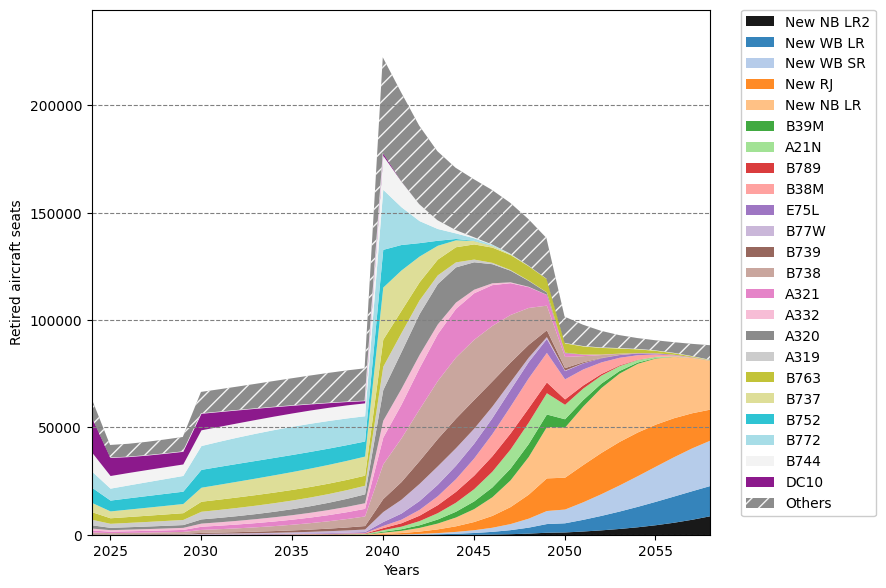

Color choice...
Coloriage trouvé : {0: 0, 18: 1, 6: 2, 26: 3, 12: 4, 35: 5, 51: 6, 50: 7, 16: 8, 29: 9, 52: 10, 53: 11, 3: 12, 1: 13, 8: 14, 55: 15, 54: 16, 4: 15, 2: 16, 10: 17, 33: 13, 5: 9, 9: 7, 56: 8, 57: 12, 36: 14, 7: 6, 42: 12}
0.0%
8.6%
17.1%
25.7%
34.3%
42.9%
51.4%
60.0%
68.6%
77.1%
85.7%
94.3%


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1400, 1000) to (1408, 1008) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


{56: 0, 57: 1, 55: 2, 54: 3, 52: 4, 53: 5, 51: 6, 50: 7, 0: 8, 18: 9, 6: 10, 26: 11, 12: 12, 16: 13, 35: 14, 29: 15, 33: 16, 19: 17, 21: 18, 42: 19, 40: 20, 44: 21, 36: 22, 45: 23, 3: 24, 8: 25, 10: 26, 15: 27, 9: 28, 24: 29, 1: 30, 47: 31, 11: 32, 20: 33, 32: 34, 2: 35, 14: 36, 38: 37, 4: 38, 37: 39, 27: 40, 5: 41, 7: 42, 25: 43, 31: 44, 23: 45, 28: 46, 46: 47, 22: 48, 43: 49, 41: 50, 39: 51, 34: 52, 13: 53, 48: 54, 17: 55}


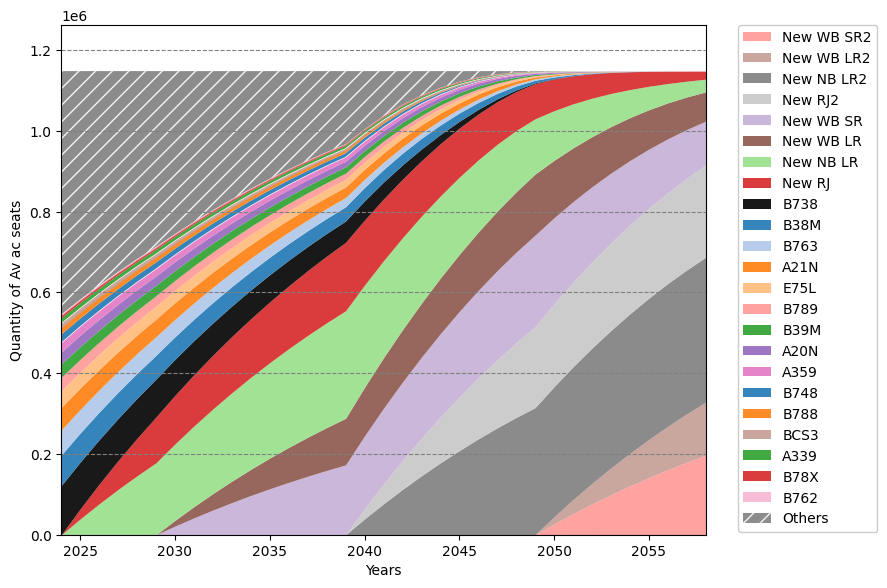

Color choice...
Coloriage trouvé : {0: 0, 6: 1, 18: 2, 26: 3, 33: 4, 35: 5, 16: 6, 51: 7, 50: 8, 53: 9, 52: 10, 3: 11, 8: 12, 55: 13, 54: 14, 1: 15, 10: 16, 29: 15, 4: 13, 5: 14, 12: 12, 57: 11, 56: 16, 2: 9, 11: 10, 40: 17, 36: 6, 7: 7}
0.0%
8.6%
17.1%
25.7%
34.3%
42.9%
51.4%
60.0%
68.6%
77.1%
85.7%
94.3%


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1400, 1000) to (1408, 1008) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


{57: 0, 56: 1, 55: 2, 54: 3, 53: 4, 52: 5, 51: 6, 50: 7, 0: 8, 6: 9, 18: 10, 26: 11, 16: 12, 33: 13, 35: 14, 19: 15, 12: 16, 29: 17, 21: 18, 40: 19, 44: 20, 42: 21, 36: 22, 45: 23, 3: 24, 10: 25, 8: 26, 15: 27, 9: 28, 24: 29, 1: 30, 47: 31, 11: 32, 20: 33, 32: 34, 2: 35, 14: 36, 38: 37, 4: 38, 37: 39, 27: 40, 5: 41, 7: 42, 31: 43, 25: 44, 23: 45, 28: 46, 46: 47, 22: 48, 43: 49, 41: 50, 39: 51, 34: 52, 13: 53, 48: 54, 17: 55}


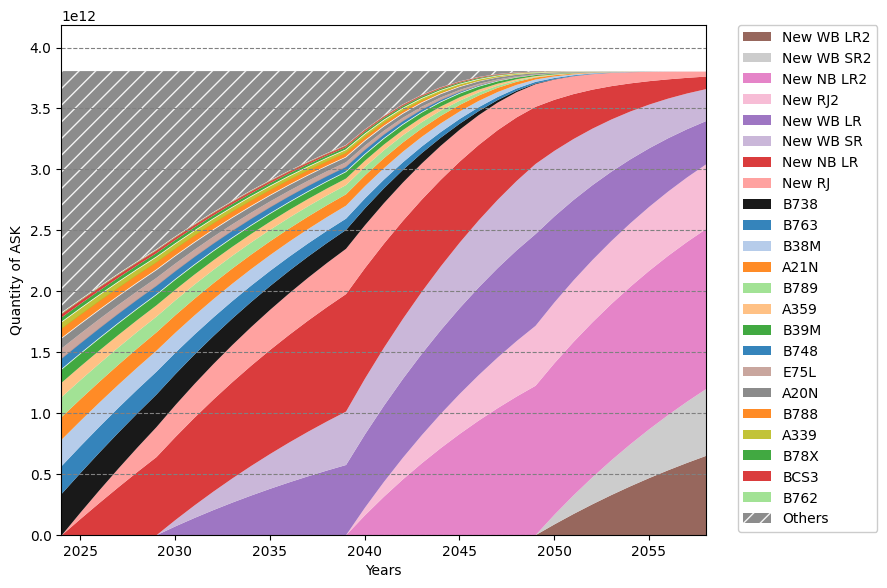

Color choice...
Coloriage trouvé : {12: 0, 0: 1, 6: 2, 18: 3, 26: 4, 29: 5, 51: 6, 50: 7, 8: 8, 53: 9, 3: 10, 52: 11, 10: 12, 55: 13, 1: 14, 54: 15, 2: 15, 33: 14, 9: 13, 11: 11, 16: 12, 7: 9, 42: 10, 57: 8, 56: 16, 4: 7, 22: 6, 36: 10}
0.0%
8.6%
17.1%
25.7%
34.3%
42.9%
51.4%
60.0%
68.6%
77.1%
85.7%
94.3%


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1400, 1000) to (1408, 1008) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


{57: 0, 56: 1, 55: 2, 54: 3, 53: 4, 52: 5, 51: 6, 50: 7, 12: 8, 0: 9, 6: 10, 18: 11, 26: 12, 29: 13, 33: 14, 16: 15, 21: 16, 19: 17, 42: 18, 45: 19, 40: 20, 44: 21, 35: 22, 36: 23, 3: 24, 8: 25, 10: 26, 15: 27, 9: 28, 24: 29, 1: 30, 47: 31, 11: 32, 20: 33, 32: 34, 2: 35, 14: 36, 38: 37, 4: 38, 37: 39, 27: 40, 7: 41, 23: 42, 5: 43, 25: 44, 31: 45, 28: 46, 46: 47, 22: 48, 43: 49, 41: 50, 34: 51, 39: 52, 13: 53, 48: 54, 17: 55}


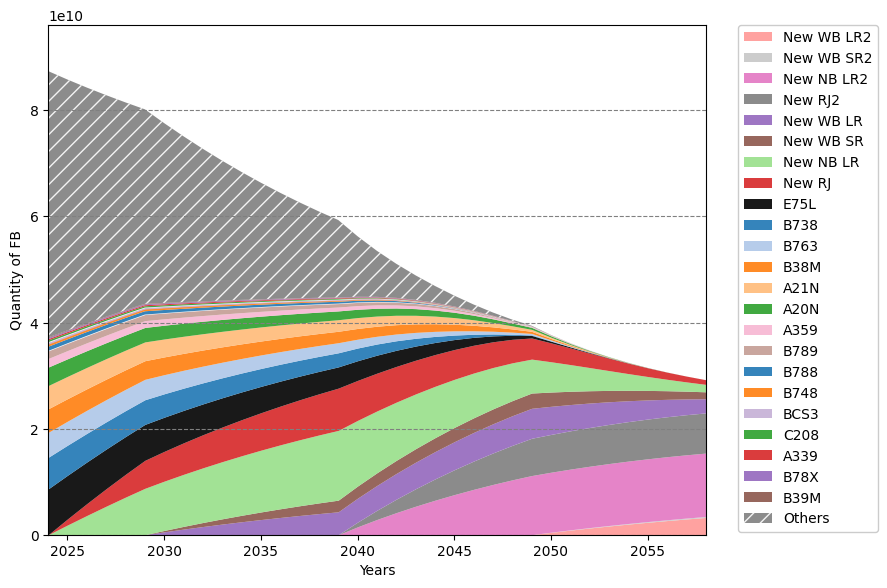

In [152]:
type_obs, omegas_l, assignments = global_modelling.scenario(initial_fleet,deliveries,obs_sizes,traffic_structures,propensions,alphas,betas, omegas_0,ranges, 
                                                            types_names = types_names, aging_activity_coeff=aging_activity_coeff, period_duration = period_duration,
                                                            taux_utilisation_usuel=taux_utilisation_usuel, name_video = 'icao_ref_us_sc_aging0', 
                                                            dic_fuel = dico_seymm, vals_fuel = fb_ini)

In [167]:
type_obs, omegas_l, assignments = global_modelling.scenario(initial_fleet,deliveries,obs_sizes,traffic_structures,propensions,alphas,betas, omegas_0,ranges, 
                                                            types_names = types_names, aging_activity_coeff=aging_activity_coeff, period_duration = period_duration,
                                                            taux_utilisation_usuel=taux_utilisation_usuel, name_video = 'icao_ref_us_sc_aging0', 
                                                            dic_fuel = dico_seymm, vals_fuel = fb_ini)

Period 0,total fleet: 1160489.6438194264
total constraint: 1148118.2104247417
Fleet content, ok.
Fleet assignment, ok.
Period 0 done.
Period 1,total fleet: 1221689.6438194264
total constraint: 1148118.2104247417
Fleet content, ok.
Fleet assignment, ok.
Period 1 done.
Period 2,total fleet: 1282889.6438194264
total constraint: 1148118.2104247417
Fleet content, ok.
Fleet assignment, ok.
Period 2 done.
Period 3,total fleet: 1344089.6438194264
total constraint: 1148118.2104247417
Fleet content, ok.
Fleet assignment, ok.
Period 3 done.
Period 4,total fleet: 1405289.6438194264
total constraint: 1148118.2104247417
Fleet content, ok.
Fleet assignment, ok.
Period 4 done.
Period 5,total fleet: 1466489.6438194264
total constraint: 1148118.2104247417
Fleet content, ok.
Fleet assignment, ok.
Period 5 done.
Period 6,total fleet: 1531089.6438194264
total constraint: 1148118.2104247417
Fleet content, ok.
Fleet assignment, ok.
Period 6 done.
Period 7,total fleet: 1595689.6438194264
total constraint: 114

RecursionError: maximum recursion depth exceeded

# Test Fuels burns

In [53]:
a = np.array([1,0])
np.diff(a)

array([-1])

In [31]:
resultat = list(set(a) - set(b))

In [32]:
resultat

[]